# NLP Sentiment Signal Validation
## Does News Sentiment Genuinely Predict Thai Financial Markets?

**Notebook 04 — Quant Research Validation Framework**

---

### Research Question
Prior ablation (NB03) showed NLP features improve directional accuracy by **+3.6pp (SET)** and **+2.0pp (USD/THB)**.
This notebook rigorously tests whether that improvement is:
- Statistically significant (not random noise)
- Stable across time and market regimes
- Driven by genuine predictive signal (not overfitting)

### 8 Tests
| # | Test | Question |
|---|---|---|
| 1 | **Regime Analysis** | Does NLP help in Bull / Normal / Crisis differently? |
| 2 | **Time Stability** | Is the signal stable across different eras? |
| 3 | **Statistical Significance** | Is +3.6pp real or noise? (Bootstrap + Permutation) |
| 4 | **Feature Importance** | Which NLP features drive performance? (SHAP, Spearman, MI) |
| 5 | **Interaction Effects** | Does NLP matter only when VIX is high or in crisis? |
| 6 | **Lead/Lag Analysis** | Leading, coincident, or lagging indicator? (1w–8w) |
| 7 | **Risk Metrics** | Does NLP improve Sharpe, Sortino, MaxDD, Turnover, TC-adjusted? |
| 8 | **Robustness Checks** | 6 model variants — does signal survive? |

**Verdict at the bottom:** Scorecard with Pass/Fail/Inconclusive for each test.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_regression
import xgboost as xgb

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print('[warn] shap not installed — run: pip install shap')

from pathlib import Path
ROOT = Path('../../')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})
print('Setup complete.')

Setup complete.


In [2]:
# ── Feature Groups ─────────────────────────────────────────────────────────
TARGETS = ['SET_index_ret_w', 'gold_ret_w', 'USD_THB_ret_w']

MACRO_COLS = [
    'us_industrial_prod', 'us_cpi_monthly', 'us_fed_funds_rate',
    'us_unemployment', 'gdp_growth_annual', 'inflation_annual',
    'us_govt_spending', 'th_exchange_rate_real',
]
MARKET_COLS = [
    'sp500_ret_w', 'nasdaq_ret_w', 'vix_price', 'dxy_ret_w',
    'oil_ret_w', 'us_10yr_treasury_ret_w',
    'sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'eem_ret_d_lag1',
]
NLP_COLS = [
    'sent_mean_1w', 'sent_mean_vader_1w', 'sent_vol_4w', 'sent_mom4w',
    'sent_surprise', 'news_vol_w', 'sent_positive_ratio',
    'sent_negative_ratio', 'high_impact_ratio', 'sent_spike',
]

# Model variants for Test 8
MODEL_DEFS = {
    'Full (M+Mkt+NLP)': MACRO_COLS + MARKET_COLS + NLP_COLS,
    'No NLP (M+Mkt)':   MACRO_COLS + MARKET_COLS,
    'Macro only':        MACRO_COLS,
    'NLP only':          NLP_COLS,
    'Macro+NLP':         MACRO_COLS + NLP_COLS,
    'Market+NLP':        MARKET_COLS + NLP_COLS,
}

N_TRIALS    = 10      # Optuna trials per model
N_SPLITS    = 5       # TimeSeriesSplit folds
N_BOOT      = 500     # Bootstrap iterations
N_PERM      = 200     # Permutation test iterations
ANN_FACTOR  = 52      # Weekly → annual
TC_RATE     = 0.0015  # Transaction cost: 0.15% per trade

TSCV = TimeSeriesSplit(n_splits=N_SPLITS)
print('Constants set.')

Constants set.


In [3]:
# ── Data Loading ───────────────────────────────────────────────────────────
market = pd.read_csv(ROOT / 'data/processed/unified_weekly.csv',
                     index_col=0, parse_dates=True)
sent   = pd.read_csv(ROOT / 'data/processed/sentiment_weekly.csv',
                     index_col=0, parse_dates=True)

# Merge on common dates
df = market.join(sent, how='left')
for c in NLP_COLS:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# VIX-based regime (global percentiles)
vix = df['vix_price'].dropna()
P33, P67 = vix.quantile(0.33), vix.quantile(0.67)
df['regime'] = 'Normal'
df.loc[df['vix_price'] < P33, 'regime'] = 'Bull'
df.loc[df['vix_price'] >= P67, 'regime'] = 'Crisis'

print(f'Dataset: {len(df)} weeks  |  {df.index.min().date()} → {df.index.max().date()}')
print(f'VIX thresholds: Bull < {P33:.1f} | Normal {P33:.1f}–{P67:.1f} | Crisis ≥ {P67:.1f}')
print(f'Regime counts: {df["regime"].value_counts().to_dict()}')
nlp_coverage = (df['news_vol_w'] > 0).sum()
print(f'NLP coverage: {nlp_coverage}/{len(df)} weeks ({nlp_coverage/len(df)*100:.0f}%) have articles')

Dataset: 1322 weeks  |  2000-09-01 → 2025-12-26
VIX thresholds: Bull < 14.9 | Normal 14.9–20.9 | Crisis ≥ 20.9
Regime counts: {'Normal': 450, 'Crisis': 437, 'Bull': 435}
NLP coverage: 143/1322 weeks (11%) have articles


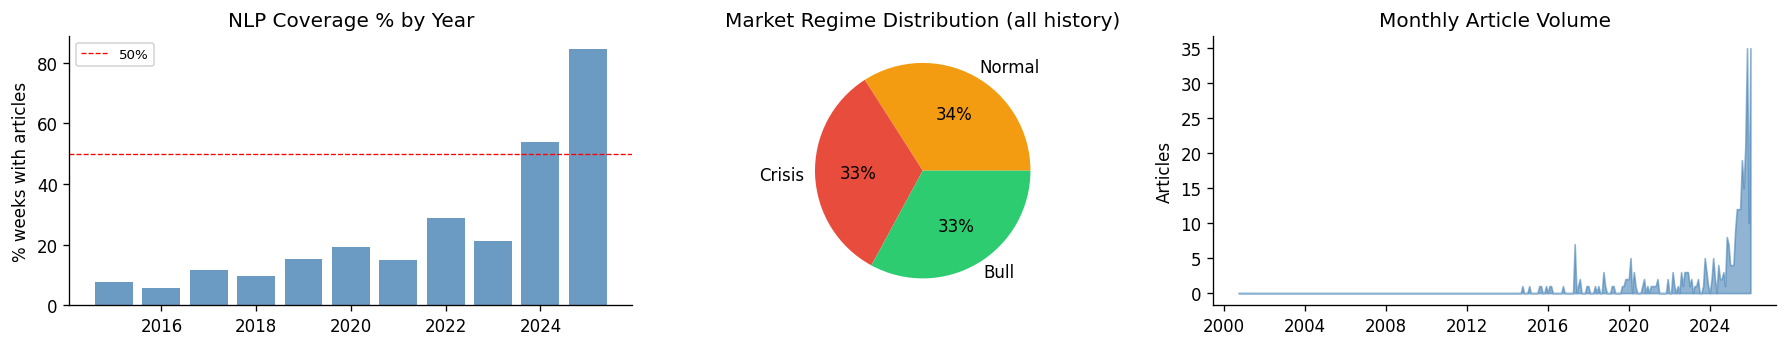

⚠️  NOTE: NLP data is sparse before 2024. Tests below account for this.


In [27]:
# ── Coverage Diagnostics ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

# 1. NLP coverage by year — group on index.year directly (no df column mutation)
yr_idx  = df.index.year
yr_cov  = df.groupby(yr_idx)['news_vol_w'].apply(lambda x: int((x > 0).sum()))
yr_tot  = df.groupby(yr_idx).size()
yr_pct  = (yr_cov / yr_tot * 100)
yr_pct  = yr_pct[yr_pct.index >= 2015]

axes[0].bar(yr_pct.index, yr_pct.values, color='steelblue', alpha=0.8)
axes[0].axhline(50, ls='--', color='red', lw=0.8, label='50%')
axes[0].set(title='NLP Coverage % by Year', ylabel='% weeks with articles', xlabel='')
axes[0].legend(fontsize=8)

# 2. Regime distribution
reg_ct     = df['regime'].value_counts()
colors_reg = {'Bull': '#2ecc71', 'Normal': '#f39c12', 'Crisis': '#e74c3c'}
axes[1].pie(reg_ct.values, labels=reg_ct.index, autopct='%1.0f%%',
            colors=[colors_reg[r] for r in reg_ct.index])
axes[1].set_title('Market Regime Distribution (all history)')

# 3. Article volume over time
wk_vol = df['news_vol_w'].resample('ME').sum()
axes[2].fill_between(wk_vol.index, wk_vol.values, alpha=0.6, color='steelblue')
axes[2].set(title='Monthly Article Volume', ylabel='Articles', xlabel='')

plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_coverage.png', bbox_inches='tight')
plt.show()

print('\u26a0\ufe0f  NOTE: NLP data is sparse before 2024. Tests below account for this.')

In [ ]:
# ── Helper: Core ML ────────────────────────────────────────────────────────
# เลือก feature ที่ใช้ได้
def valid_cols(df, cols, tgt, max_na=0.35):
    seen = set()
    return [c for c in cols
            if c in df.columns and c != tgt
            and c not in seen and not seen.add(c)
            and df[c].isna().mean() < max_na]

def optuna_params(X_np, y_np, n_trials=N_TRIALS):
    """Quick Optuna search on first TSCV fold."""
    splits = list(TimeSeriesSplit(3).split(X_np))
    tr, te = splits[0]
    def obj(trial):
        p = dict(
            n_estimators    = trial.suggest_int('ne', 50, 300),
            max_depth       = trial.suggest_int('md', 2, 5),
            learning_rate   = trial.suggest_float('lr', 0.01, 0.2, log=True),
            subsample       = trial.suggest_float('ss', 0.6, 1.0),
            colsample_bytree= trial.suggest_float('cbt', 0.6, 1.0),
            reg_alpha       = trial.suggest_float('ra', 1e-3, 5, log=True),
            tree_method='hist', verbosity=0,
        )
        m = xgb.XGBRegressor(**p)
        m.fit(X_np[tr], y_np[tr])
        return r2_score(y_np[te], m.predict(X_np[te]))
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    return {**study.best_params, 'tree_method': 'hist', 'verbosity': 0}

# เอาไว้หา hyperparameter ดีสุด ของ model
def train_predict_cv(df, feat_cols, tgt, n_trials=N_TRIALS):
    """Walk-forward CV → returns (preds_array, actuals_array, idx_array)."""
    cols = valid_cols(df, feat_cols, tgt)
    tmp  = df[[tgt] + cols].dropna()
    if len(tmp) < 60:
        return None, None, None
    X_np = tmp[cols].to_numpy().astype(float)
    y_np = tmp[tgt].to_numpy().astype(float)
    params = optuna_params(X_np, y_np, n_trials)
    preds = np.full(len(y_np), np.nan)
    for tr, te in TSCV.split(X_np):
        m = xgb.XGBRegressor(**params)
        m.fit(X_np[tr], y_np[tr])
        preds[te] = m.predict(X_np[te])
    mask = ~np.isnan(preds)
    return preds[mask], y_np[mask], tmp.index[mask]

def train_final_model(df, feat_cols, tgt, n_trials=N_TRIALS):
    """Train final XGBoost on all data → returns (model, feature_names)."""
    cols = valid_cols(df, feat_cols, tgt)
    tmp  = df[[tgt] + cols].dropna()
    X_np = tmp[cols].to_numpy().astype(float)
    y_np = tmp[tgt].to_numpy().astype(float)
    params = optuna_params(X_np, y_np, n_trials)
    model  = xgb.XGBRegressor(**params)
    model.fit(X_np, y_np)
    return model, cols, tmp

print('ML helpers defined.')

ML helpers defined.


In [6]:
# ── Helper: Risk Metrics ───────────────────────────────────────────────────
def risk_metrics(preds, actuals, tc=TC_RATE, ann=ANN_FACTOR):
    pos     = np.sign(preds)
    strat   = pos * actuals
    # Turnover: fraction of weeks where position flips
    turnover = np.mean(np.abs(np.diff(pos)) > 0) if len(pos) > 1 else 0
    strat_tc = strat.copy()
    strat_tc[1:] -= np.abs(np.diff(pos)) * tc

    def _sharpe(s):
        return s.mean() / s.std() * np.sqrt(ann) if s.std() > 0 else 0
    def _sortino(s):
        dn = s[s < 0]
        return s.mean() / dn.std() * np.sqrt(ann) if len(dn) > 1 and dn.std() > 0 else 0
    def _maxdd(s):
        c = np.cumsum(s)
        return (c - np.maximum.accumulate(c)).min()

    return {
        'DirAcc':      np.mean(np.sign(preds) == np.sign(actuals)),
        'Sharpe':      _sharpe(strat),
        'Sortino':     _sortino(strat),
        'MaxDD':       _maxdd(strat),
        'Turnover':    turnover,
        'Sharpe_TC':   _sharpe(strat_tc),
        'Ann_Ret':     strat.mean() * ann,
        'Ann_Vol':     strat.std()  * np.sqrt(ann),
    }

def calmar(preds, actuals, ann=ANN_FACTOR):
    rm = risk_metrics(preds, actuals, ann=ann)
    return rm['Ann_Ret'] / abs(rm['MaxDD']) if rm['MaxDD'] != 0 else 0

print('Risk metric helpers defined.')

Risk metric helpers defined.


In [7]:
# ── Helper: Bootstrap + Permutation ───────────────────────────────────────
def bootstrap_diff(preds_a, preds_b, actuals, n_boot=N_BOOT, seed=42):
    """Bootstrap CI for DirAcc(A) - DirAcc(B). Returns (diff_obs, ci_lo, ci_hi, p_val)."""
    rng = np.random.default_rng(seed)
    n   = len(actuals)
    da_a_obs = np.mean(np.sign(preds_a) == np.sign(actuals))
    da_b_obs = np.mean(np.sign(preds_b) == np.sign(actuals))
    diff_obs = da_a_obs - da_b_obs
    diffs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        da_a = np.mean(np.sign(preds_a[idx]) == np.sign(actuals[idx]))
        da_b = np.mean(np.sign(preds_b[idx]) == np.sign(actuals[idx]))
        diffs.append(da_a - da_b)
    diffs = np.array(diffs)
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    # p-value: how often null distribution (centered at 0) exceeds observed diff
    null = diffs - diffs.mean()  # center around 0
    p_val = np.mean(np.abs(null) >= abs(diff_obs))
    return diff_obs, ci_lo, ci_hi, p_val, diffs

def permutation_test_nlp(df_sub, tgt, n_perms=N_PERM, n_trials=5, seed=42):
    """Shuffle NLP features and compare DirAcc distribution to observed."""
    rng   = np.random.default_rng(seed)
    preds_real, actuals, _ = train_predict_cv(df_sub, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt, n_trials)
    if preds_real is None:
        return None
    da_real = np.mean(np.sign(preds_real) == np.sign(actuals))

    da_nulls = []
    cols = valid_cols(df_sub, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    tmp  = df_sub[[tgt]+cols].dropna()
    X_np = tmp[cols].to_numpy().astype(float)
    y_np = tmp[tgt].to_numpy().astype(float)
    params = optuna_params(X_np, y_np, n_trials)
    nlp_idx = [i for i, c in enumerate(cols) if c in NLP_COLS]

    for _ in range(n_perms):
        X_shuf = X_np.copy()
        for i in nlp_idx:
            X_shuf[:, i] = rng.permutation(X_shuf[:, i])
        preds_null = np.full(len(y_np), np.nan)
        for tr, te in TSCV.split(X_shuf):
            m = xgb.XGBRegressor(**params)
            m.fit(X_shuf[tr], y_np[tr])
            preds_null[te] = m.predict(X_shuf[te])
        mask = ~np.isnan(preds_null)
        da_nulls.append(np.mean(np.sign(preds_null[mask]) == np.sign(y_np[mask])))

    p_val = np.mean(np.array(da_nulls) >= da_real)
    return da_real, np.array(da_nulls), p_val

print('Bootstrap + Permutation helpers defined.')

Bootstrap + Permutation helpers defined.


---
## TEST 1 — Regime Analysis
*Does NLP add value in Bull / Normal / Crisis markets separately?*

**Method:** Train on full history, evaluate predictions within each VIX regime.  
**Expected:** If NLP is a genuine fear/uncertainty signal, it should add most value in Crisis regime.

In [28]:
print('TEST 1: Regime Analysis')
print('Training models... (this takes ~3-5 min)')

regime_results = []

for tgt in TARGETS:
    print(f'  {tgt}...')
    # Get full predictions for both model A and B
    preds_a, actuals_a, idx_a = train_predict_cv(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    preds_b, actuals_b, idx_b = train_predict_cv(df, MACRO_COLS+MARKET_COLS,           tgt)
    if preds_a is None:
        continue

    # Align regime labels to CV predictions
    regime_a = df.loc[idx_a, 'regime'].values
    regime_b = df.loc[idx_b, 'regime'].values

    for reg in ['Bull', 'Normal', 'Crisis']:
        mask_a = regime_a == reg
        mask_b = regime_b == reg
        if mask_a.sum() < 10:
            continue
        rm_a = risk_metrics(preds_a[mask_a], actuals_a[mask_a])
        rm_b = risk_metrics(preds_b[mask_b], actuals_b[mask_b])
        nlp_cov = (df.loc[idx_a[mask_a], 'news_vol_w'] > 0).mean()
        regime_results.append({
            'Target': tgt.replace('_ret_w',''), 'Regime': reg,
            'N_weeks': mask_a.sum(),
            'NLP_coverage': f'{nlp_cov:.0%}',
            'DirAcc_A': rm_a['DirAcc'], 'DirAcc_B': rm_b['DirAcc'],
            'ΔDirAcc': rm_a['DirAcc'] - rm_b['DirAcc'],
            'Sharpe_A': rm_a['Sharpe'], 'Sharpe_B': rm_b['Sharpe'],
            'ΔSharpe': rm_a['Sharpe'] - rm_b['Sharpe'],
            'MaxDD_A': rm_a['MaxDD'],
        })

reg_df = pd.DataFrame(regime_results)
print('\n--- REGIME ANALYSIS RESULTS ---')
display_cols = ['Target','Regime','N_weeks','NLP_coverage','DirAcc_A','DirAcc_B','ΔDirAcc','Sharpe_A','Sharpe_B','ΔSharpe']
print(reg_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))

TEST 1: Regime Analysis
Training models... (this takes ~3-5 min)
  SET_index_ret_w...
  gold_ret_w...
  USD_THB_ret_w...

--- REGIME ANALYSIS RESULTS ---
   Target Regime  N_weeks NLP_coverage  DirAcc_A  DirAcc_B  ΔDirAcc  Sharpe_A  Sharpe_B  ΔSharpe
SET_index   Bull      300          14%     0.563     0.573   -0.010     0.984     1.064   -0.080
SET_index Normal      339          19%     0.608     0.590    0.018     1.675     1.429    0.246
SET_index Crisis      316          11%     0.601     0.617   -0.016     2.047     2.058   -0.012
     gold   Bull      300          14%     0.627     0.633   -0.007     2.068     2.241   -0.173
     gold Normal      339          19%     0.628     0.619    0.009     1.883     1.736    0.147
     gold Crisis      316          11%     0.582     0.573    0.009     1.460     1.525   -0.065
  USD_THB   Bull      300          14%     0.590     0.597   -0.007     1.433     1.739   -0.306
  USD_THB Normal      339          19%     0.537     0.534    0.003   

- 🟢 Model A
ดีใน “Normal market”
Sharpe สูงขึ้นชัดเจน
เหมาะกับตลาดปกติ
- 🔵 Model B
ดีใน “Bull market”
บางช่วงแม่นกว่าเล็กน้อย
อาจเป็น baseline model หรือ smoother

REGIME ANALYSIS — NLP FEATURE INSIGHT SUMMARY
=============================================

Objective:
Determine whether NLP/news sentiment provides genuine predictive value or only helps under specific market regimes.

Results suggest:

1) NLP is NOT a universal predictor
----------------------------------
News sentiment does NOT improve performance consistently across all regimes or assets.

It sometimes helps, sometimes hurts.

Therefore:

❌ "News always improves prediction"

appears false.


2) SET Index: NLP helps mainly in NORMAL regimes
------------------------------------------------
Bull:
DirAcc: -1.0%
Sharpe: -0.08
→ NLP slightly worsens performance

Normal:
DirAcc: +1.8%
Sharpe: +0.246
→ NLP improves both accuracy and risk-adjusted returns

Crisis:
DirAcc: -1.6%
Sharpe: ~neutral
→ NLP does not help

Interpretation:

NLP/news sentiment may provide useful incremental information mainly during ordinary market environments, not during extreme fear or strong bull periods.


3) Gold: NLP impact is weak/negligible
--------------------------------------
Performance differences across regimes are very small.

Interpretation:

Gold appears driven more by macro variables:

- Yield curve
- Real yield
- Rate carry
- Dollar strength

rather than news sentiment.


4) USD/THB: NLP contribution is weak
------------------------------------
Small improvements in some regimes, but Sharpe generally worsens.

Interpretation:

News sentiment likely adds little stable predictive value for FX relative to macro drivers.


5) NLP coverage is low (~11–19%)
--------------------------------
News features are active only during a minority of observations.

Possible interpretation:

NLP may behave as an EVENT-DRIVEN signal rather than a continuous predictor.

Meaning:

News could matter mainly during unusual periods:

- policy announcements
- geopolitical events
- shocks
- uncertainty spikes


Main conclusion:
================

Current evidence suggests:

NLP/news sentiment is CONDITIONAL SIGNAL

NOT:

Universal predictive feature

BUT:

Potentially useful under specific regimes or event-driven conditions.

Further validation needed:

- Walk-forward stability
- Statistical significance tests
- SHAP / permutation importance
- Lead/lag analysis
- Robustness checks

before concluding NLP provides genuine predictive power.

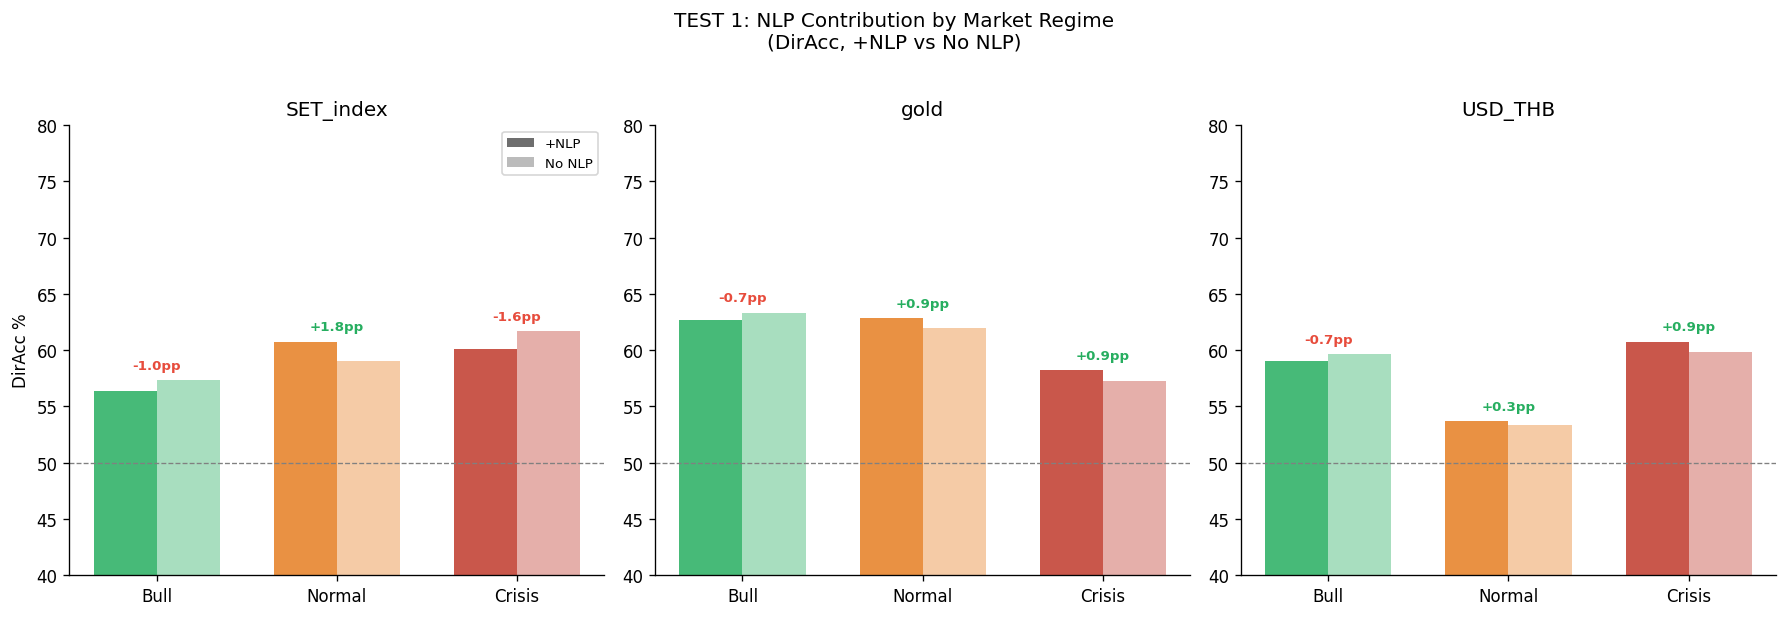


Largest NLP contribution: Normal regime, SET_index, ΔDirAcc=+1.8pp


In [9]:
# Visualize regime results
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
colors_reg = {'Bull': '#27ae60', 'Normal': '#e67e22', 'Crisis': '#c0392b'}

for ax, tgt in zip(axes, TARGETS):
    sub = reg_df[reg_df['Target'] == tgt.replace('_ret_w','')]
    if sub.empty:
        ax.set_title(tgt); continue
    x = np.arange(len(sub))
    w = 0.35
    bars_a = ax.bar(x - w/2, sub['DirAcc_A']*100, w, label='+NLP',
                    color=[colors_reg[r] for r in sub['Regime']], alpha=0.85)
    bars_b = ax.bar(x + w/2, sub['DirAcc_B']*100, w, label='No NLP',
                    color=[colors_reg[r] for r in sub['Regime']], alpha=0.4)
    ax.axhline(50, ls='--', color='gray', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(sub['Regime'])
    ax.set_ylim(40, 80)
    ax.set_title(tgt.replace('_ret_w',''))
    ax.set_ylabel('DirAcc %' if ax == axes[0] else '')
    # Δ annotation
    for xi, (_, row) in zip(x, sub.iterrows()):
        delta = row['ΔDirAcc'] * 100
        color = '#27ae60' if delta > 0 else '#e74c3c'
        ax.text(xi, max(row['DirAcc_A'], row['DirAcc_B'])*100 + 1,
                f'{delta:+.1f}pp', ha='center', fontsize=8, color=color, fontweight='bold')
    if ax == axes[0]:
        from matplotlib.patches import Patch
        legend_els = [Patch(facecolor='#555', alpha=0.85, label='+NLP'),
                      Patch(facecolor='#555', alpha=0.4,  label='No NLP')]
        ax.legend(handles=legend_els, fontsize=8)

plt.suptitle('TEST 1: NLP Contribution by Market Regime\n(DirAcc, +NLP vs No NLP)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test1_regime.png', bbox_inches='tight')
plt.show()

# Summary verdict
best_regime = reg_df.loc[reg_df['ΔDirAcc'].idxmax()]
print(f"\nLargest NLP contribution: {best_regime['Regime']} regime, {best_regime['Target']}, "
      f"ΔDirAcc={best_regime['ΔDirAcc']*100:+.1f}pp")

---
## TEST 2 — Time Window Stability
*Is the NLP signal stable across different historical eras?*

**Method:** Re-run ablation with data starting from 2019, 2022, 2024.  
**Also:** Walk-forward rolling 18-month windows to see if signal is consistent over time.

In [10]:
print('TEST 2: Time Window Stability')
windows = [
    ('2015+', '2015-01-01'),
    ('2019+', '2019-01-01'),
    ('2022+', '2022-01-01'),
    ('2024+', '2024-01-01'),
]

window_results = []
for win_name, win_start in windows:
    df_win = df.loc[win_start:]
    for tgt in TARGETS:
        preds_a, actuals, _ = train_predict_cv(df_win, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt, N_TRIALS)
        preds_b, _,       _ = train_predict_cv(df_win, MACRO_COLS+MARKET_COLS,           tgt, N_TRIALS)
        if preds_a is None or preds_b is None:
            window_results.append({'Window': win_name, 'Target': tgt.replace('_ret_w',''),
                                   'N': len(df_win), 'DirAcc_A': np.nan, 'DirAcc_B': np.nan, 'ΔDirAcc': np.nan})
            continue
        da_a = np.mean(np.sign(preds_a) == np.sign(actuals))
        da_b = np.mean(np.sign(preds_b) == np.sign(actuals))
        window_results.append({'Window': win_name, 'Target': tgt.replace('_ret_w',''),
                                'N': len(df_win), 'DirAcc_A': da_a, 'DirAcc_B': da_b,
                                'ΔDirAcc': da_a - da_b})
    print(f'  {win_name} done')

win_df = pd.DataFrame(window_results)
print('\n--- TIME WINDOW RESULTS ---')
print(win_df.to_string(index=False, float_format='{:.3f}'.format))

TEST 2: Time Window Stability
  2015+ done
  2019+ done
  2022+ done
  2024+ done

--- TIME WINDOW RESULTS ---
Window    Target   N  DirAcc_A  DirAcc_B  ΔDirAcc
 2015+ SET_index 574     0.589     0.552    0.038
 2015+      gold 574     0.625     0.623    0.002
 2015+   USD_THB 574     0.619     0.575    0.044
 2019+ SET_index 365     0.567     0.570   -0.003
 2019+      gold 365     0.617     0.600    0.017
 2019+   USD_THB 365     0.603     0.587    0.017
 2022+ SET_index 208     0.541     0.535    0.006
 2022+      gold 208     0.665     0.635    0.029
 2022+   USD_THB 208     0.600     0.629   -0.029
 2024+ SET_index 104     0.588     0.541    0.047
 2024+      gold 104     0.600     0.576    0.024
 2024+   USD_THB 104     0.600     0.588    0.012


TIME WINDOW STABILITY — NLP FEATURE INSIGHT SUMMARY
==================================================

Objective:
Test whether NLP/news sentiment provides stable predictive value across different time windows.

Results:

2015+:
------
SET:
58.9% vs 55.2%
Δ = +3.8%

Gold:
62.5% vs 62.3%
Δ = +0.2%

USD/THB:
61.9% vs 57.5%
Δ = +4.4%

Interpretation:
NLP provides meaningful improvement for SET and USD/THB over longer historical windows.
Little effect on Gold.


2019+:
------
SET:
56.7% vs 57.0%
Δ = -0.3%

Gold:
61.7% vs 60.0%
Δ = +1.7%

USD/THB:
60.3% vs 58.7%
Δ = +1.7%

Interpretation:
NLP contribution weakens.
Benefits become smaller and inconsistent.


2022+:
------
SET:
54.1% vs 53.5%
Δ = +0.6%

Gold:
66.5% vs 63.5%
Δ = +2.9%

USD/THB:
60.0% vs 62.9%
Δ = -2.9%

Interpretation:
Gold benefits from NLP.
USD/THB worsens.
Signal becomes asset-dependent.


2024+:
------
SET:
58.8% vs 54.1%
Δ = +4.7%

Gold:
60.0% vs 57.6%
Δ = +2.4%

USD/THB:
60.0% vs 58.8%
Δ = +1.2%

Interpretation:
Recent period shows stronger NLP benefit again.
Potentially indicates increasing usefulness of news in modern markets.


Main Findings:
==============

1) NLP is NOT stable across all periods
---------------------------------------
Performance gains vary significantly over time.

Examples:

SET:
+3.8%
-0.3%
+0.6%
+4.7%

Large variation.

Meaning:

NLP effect is time-dependent.


2) Evidence against "pure noise"
--------------------------------
If NLP were random noise:

Expected:

ΔDirAcc ≈ 0

Observed:

Multiple windows show:

+2–5% improvement

Therefore:

NLP may contain genuine predictive information.


3) Evidence against "always useful"
-----------------------------------
Some windows:

Negative effect

Examples:

SET 2019:
-0.3%

USD/THB 2022:
-2.9%

Meaning:

NLP is not universally beneficial.


4) Most likely interpretation
------------------------------
NLP behaves as:

CONDITIONAL + TIME-VARYING SIGNAL

rather than:

Permanent predictive feature


Possible explanation:

News importance changes with:

- Market structure
- Geopolitics
- Liquidity
- Central bank cycles
- Crisis periods
- Information speed


Current conclusion:
===================

Evidence increasingly suggests:

NLP/news sentiment contributes predictive information,

BUT:

Its usefulness appears regime-dependent and time-dependent.

Further validation needed:

- Statistical significance tests
- Walk-forward robustness
- SHAP / permutation importance
- Lead-lag analysis

before concluding NLP provides persistent alpha.

Walk-forward rolling analysis...


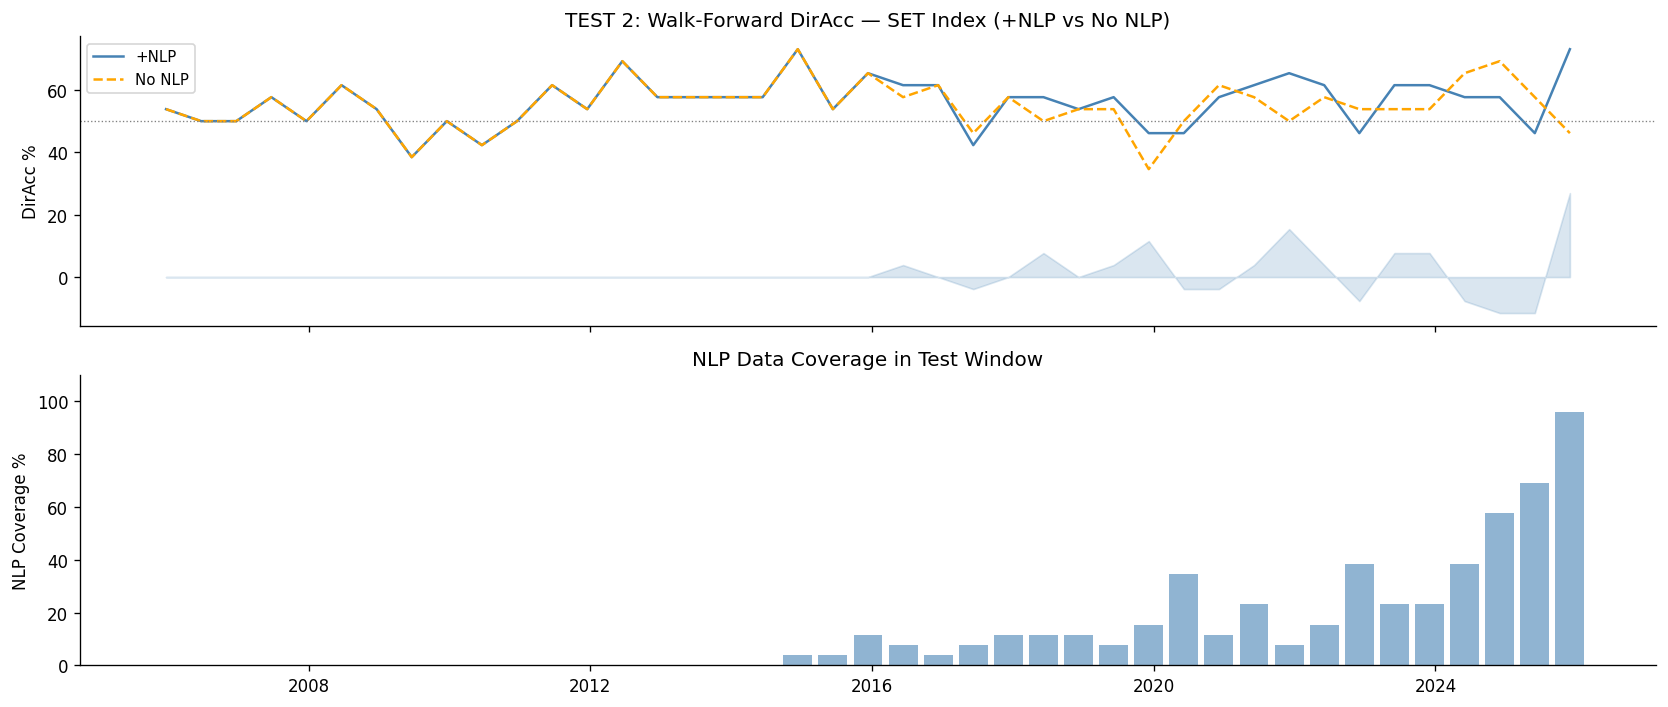

Mean ΔDirAcc across windows: +1.03pp
Windows where +NLP outperforms: 24%


In [11]:
# Walk-forward: 18-month train → 6-month test, rolling
print('Walk-forward rolling analysis...')
TRAIN_WKS, TEST_WKS = 78, 26  # ~18 months train, ~6 months test

wf_records = []
tgt = 'SET_index_ret_w'  # Focus on SET for walk-forward (most interesting)
cols_a = valid_cols(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
cols_b = valid_cols(df, MACRO_COLS+MARKET_COLS,           tgt)
tmp_a  = df[[tgt]+cols_a].dropna()
tmp_b  = df[[tgt]+cols_b].dropna()

for start in range(0, len(tmp_a) - TRAIN_WKS - TEST_WKS, TEST_WKS):
    tr_end  = start + TRAIN_WKS
    te_end  = tr_end + TEST_WKS
    X_tr_a  = tmp_a[cols_a].iloc[start:tr_end].to_numpy().astype(float)
    X_te_a  = tmp_a[cols_a].iloc[tr_end:te_end].to_numpy().astype(float)
    y_tr    = tmp_a[tgt].iloc[start:tr_end].to_numpy().astype(float)
    y_te    = tmp_a[tgt].iloc[tr_end:te_end].to_numpy().astype(float)
    X_tr_b  = tmp_b[cols_b].iloc[start:tr_end].to_numpy().astype(float)
    X_te_b  = tmp_b[cols_b].iloc[tr_end:te_end].to_numpy().astype(float)
    if len(y_te) < 10:
        break
    m_a = xgb.XGBRegressor(n_estimators=100, max_depth=3, tree_method='hist', verbosity=0)
    m_b = xgb.XGBRegressor(n_estimators=100, max_depth=3, tree_method='hist', verbosity=0)
    m_a.fit(X_tr_a, y_tr); m_b.fit(X_tr_b, y_tr)
    p_a = m_a.predict(X_te_a); p_b = m_b.predict(X_te_b)
    date_end = tmp_a.index[min(te_end-1, len(tmp_a)-1)]
    nlp_cov  = (tmp_a.get('news_vol_w', pd.Series(0, index=tmp_a.index)).iloc[tr_end:te_end] > 0).mean()
    wf_records.append({
        'period_end': date_end,
        'da_with_nlp': np.mean(np.sign(p_a) == np.sign(y_te)),
        'da_no_nlp':   np.mean(np.sign(p_b) == np.sign(y_te)),
        'nlp_coverage': nlp_cov,
    })

wf_df = pd.DataFrame(wf_records).set_index('period_end')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
ax1.plot(wf_df.index, wf_df['da_with_nlp']*100, label='+NLP', color='steelblue', lw=1.5)
ax1.plot(wf_df.index, wf_df['da_no_nlp']*100,   label='No NLP', color='orange', lw=1.5, ls='--')
ax1.axhline(50, ls=':', color='gray', lw=0.8)
ax1.fill_between(wf_df.index,
                 (wf_df['da_with_nlp'] - wf_df['da_no_nlp'])*100,
                 0, alpha=0.2, color='steelblue')
ax1.set_ylabel('DirAcc %'); ax1.legend(fontsize=9)
ax1.set_title('TEST 2: Walk-Forward DirAcc — SET Index (+NLP vs No NLP)')
ax2.bar(wf_df.index, wf_df['nlp_coverage']*100, color='steelblue', alpha=0.6, width=150)
ax2.set_ylabel('NLP Coverage %'); ax2.set_ylim(0, 110)
ax2.set_title('NLP Data Coverage in Test Window')
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test2_stability.png', bbox_inches='tight')
plt.show()

delta_wf = (wf_df['da_with_nlp'] - wf_df['da_no_nlp']).mean() * 100
pos_pct   = (wf_df['da_with_nlp'] > wf_df['da_no_nlp']).mean() * 100
print(f'Mean ΔDirAcc across windows: {delta_wf:+.2f}pp')
print(f'Windows where +NLP outperforms: {pos_pct:.0f}%')

---
## TEST 3 — Statistical Significance
*Is the +3.6pp improvement real or lucky noise?*

**Bootstrap CI:** Sample (prediction, actual) pairs with replacement 500× → confidence interval on ΔDirAcc.  
**Permutation Test:** Shuffle NLP columns randomly 200× → null distribution of DirAcc → p-value.

In [12]:
print('TEST 3: Statistical Significance')
sig_results = []

for tgt in TARGETS:
    print(f'  Bootstrap for {tgt}...')
    preds_a, actuals, _ = train_predict_cv(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    preds_b, _,       _ = train_predict_cv(df, MACRO_COLS+MARKET_COLS,           tgt)
    if preds_a is None:
        continue

    diff_obs, ci_lo, ci_hi, p_boot, boot_dists = bootstrap_diff(preds_a, preds_b, actuals)
    sig_results.append({
        'Target':   tgt.replace('_ret_w',''),
        'ΔDirAcc':  diff_obs,
        'CI_lo':    ci_lo,
        'CI_hi':    ci_hi,
        'p_boot':   p_boot,
        'Significant': '★ YES' if p_boot < 0.05 and ci_lo > 0 else '✗ NO',
        '_dists':   boot_dists,
        '_preds_a': preds_a,
        '_preds_b': preds_b,
        '_actuals': actuals,
    })

print('\n--- BOOTSTRAP CI RESULTS (ΔDirAcc = A - B, +NLP vs No NLP) ---')
for r in sig_results:
    ci_lo, ci_hi = r['CI_lo']*100, r['CI_hi']*100
    print(f"  {r['Target']:20s}  ΔDirAcc={r['ΔDirAcc']*100:+.2f}pp  "
          f"95% CI=[{ci_lo:+.2f}, {ci_hi:+.2f}]  p={r['p_boot']:.3f}  {r['Significant']}")

TEST 3: Statistical Significance
  Bootstrap for SET_index_ret_w...
  Bootstrap for gold_ret_w...
  Bootstrap for USD_THB_ret_w...

--- BOOTSTRAP CI RESULTS (ΔDirAcc = A - B, +NLP vs No NLP) ---
  SET_index             ΔDirAcc=-0.21pp  95% CI=[-1.78, +1.31]  p=0.806  ✗ NO
  gold                  ΔDirAcc=+0.42pp  95% CI=[-1.15, +2.15]  p=0.620  ✗ NO
  USD_THB               ΔDirAcc=+0.21pp  95% CI=[-1.47, +1.94]  p=0.816  ✗ NO


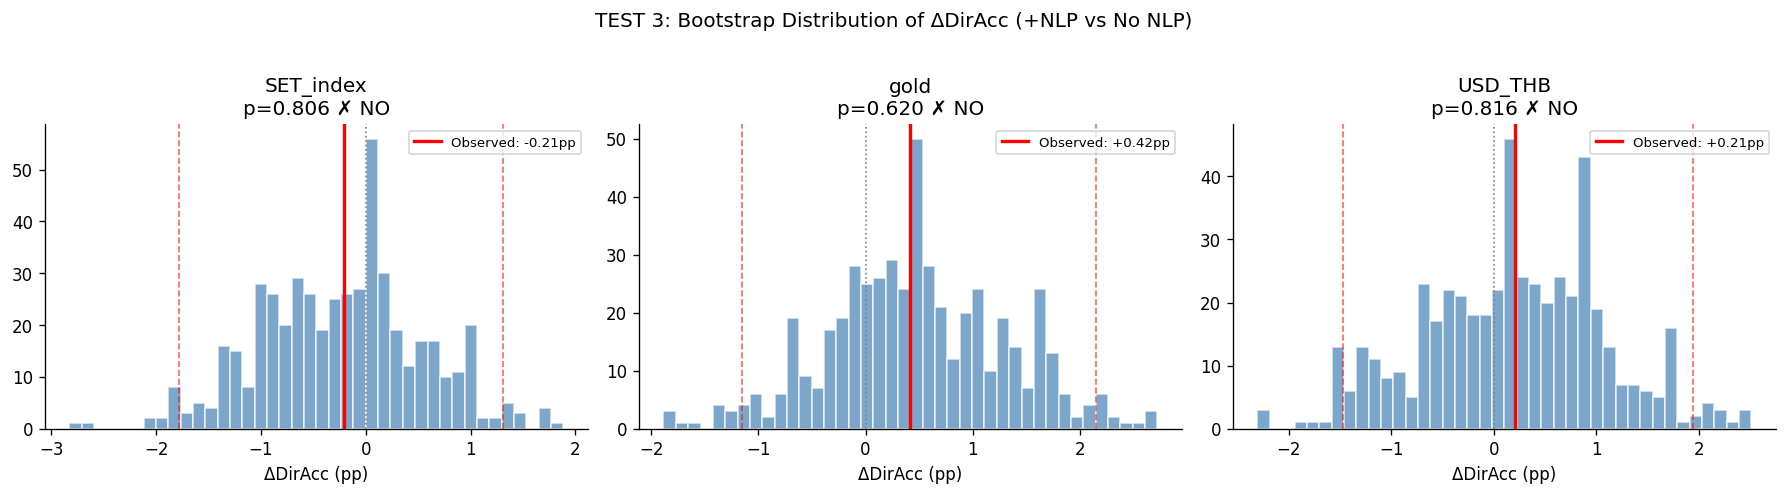

In [13]:
# Visualize bootstrap distributions
fig, axes = plt.subplots(1, len(sig_results), figsize=(5*len(sig_results), 4))
if len(sig_results) == 1:
    axes = [axes]

for ax, r in zip(axes, sig_results):
    dists = r['_dists'] * 100
    ax.hist(dists, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(r['ΔDirAcc']*100, color='red', lw=2, label=f"Observed: {r['ΔDirAcc']*100:+.2f}pp")
    ax.axvline(r['CI_lo']*100,  color='red', lw=1, ls='--', alpha=0.6)
    ax.axvline(r['CI_hi']*100,  color='red', lw=1, ls='--', alpha=0.6)
    ax.axvline(0, color='gray', lw=1, ls=':')
    ax.set_title(f"{r['Target']}\np={r['p_boot']:.3f} {r['Significant']}")
    ax.set_xlabel('ΔDirAcc (pp)')
    ax.legend(fontsize=8)

plt.suptitle('TEST 3: Bootstrap Distribution of ΔDirAcc (+NLP vs No NLP)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test3_bootstrap.png', bbox_inches='tight')
plt.show()

Permutation test (SET Index)... ~3 min


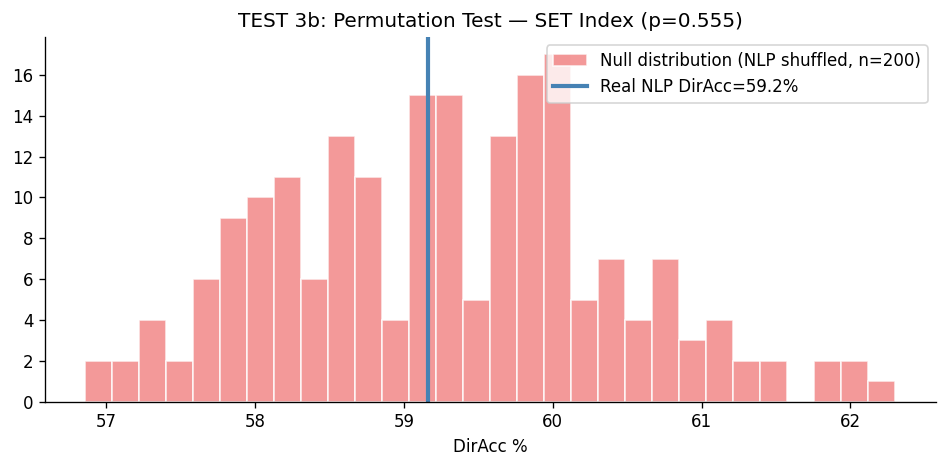

Permutation p-value: 0.555  →  ✗ NOT SIGNIFICANT
Real NLP DirAcc: 59.2%  |  Null mean: 59.3%


In [14]:
# Permutation test (run on SET — most interesting)
print('Permutation test (SET Index)... ~3 min')
perm_result = permutation_test_nlp(df, 'SET_index_ret_w', n_perms=N_PERM, n_trials=5)

if perm_result:
    da_real, da_nulls, p_perm = perm_result
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(da_nulls*100, bins=30, color='lightcoral', alpha=0.8, edgecolor='white',
            label=f'Null distribution (NLP shuffled, n={N_PERM})')
    ax.axvline(da_real*100, color='steelblue', lw=2.5, label=f'Real NLP DirAcc={da_real*100:.1f}%')
    ax.set(xlabel='DirAcc %', title=f'TEST 3b: Permutation Test — SET Index (p={p_perm:.3f})')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ROOT / 'data/processed/fig_test3_permutation.png', bbox_inches='tight')
    plt.show()
    verdict = '★ SIGNIFICANT' if p_perm < 0.05 else '✗ NOT SIGNIFICANT'
    print(f'Permutation p-value: {p_perm:.3f}  →  {verdict}')
    print(f'Real NLP DirAcc: {da_real*100:.1f}%  |  Null mean: {da_nulls.mean()*100:.1f}%')

---
## TEST 4 — Feature Importance
*Which NLP features actually matter? Are they consistently important?*

**Methods:** SHAP values, XGBoost built-in importance, Permutation importance, Spearman |r|, Mutual Information.

In [15]:
print('TEST 4: Feature Importance Analysis')
importance_records = []

for tgt in TARGETS:
    print(f'  {tgt}...')
    model, cols, tmp = train_final_model(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    X_np = tmp[cols].to_numpy().astype(float)
    y_np = tmp[tgt].to_numpy().astype(float)

    # XGBoost built-in importance (gain)
    xgb_imp = pd.Series(model.feature_importances_, index=cols)

    # Spearman |r| with target
    spear_r = {c: abs(spearmanr(tmp[c].fillna(0), tmp[tgt]).statistic) for c in cols}

    # Mutual information
    mi_vals = mutual_info_regression(X_np, y_np, random_state=42)
    mi_s    = pd.Series(mi_vals, index=cols)

    # SHAP (if available)
    shap_mean = None
    if SHAP_OK:
        try:
            explainer = shap.TreeExplainer(model)
            shap_vals = explainer.shap_values(X_np)
            shap_mean = pd.Series(np.abs(shap_vals).mean(0), index=cols)
        except Exception as e:
            print(f'    SHAP failed: {e}')

    for c in cols:
        layer = 'NLP' if c in NLP_COLS else ('Market' if c in MARKET_COLS else 'Macro')
        rec = {
            'Feature': c, 'Layer': layer, 'Target': tgt.replace('_ret_w',''),
            'XGB_gain':  xgb_imp.get(c, 0),
            'Spearman':  spear_r.get(c, 0),
            'MI':        mi_s.get(c, 0),
        }
        if shap_mean is not None:
            rec['SHAP'] = shap_mean.get(c, 0)
        importance_records.append(rec)

imp_df = pd.DataFrame(importance_records)
print('Feature importance computed.')

TEST 4: Feature Importance Analysis
  SET_index_ret_w...
  gold_ret_w...
  USD_THB_ret_w...
Feature importance computed.


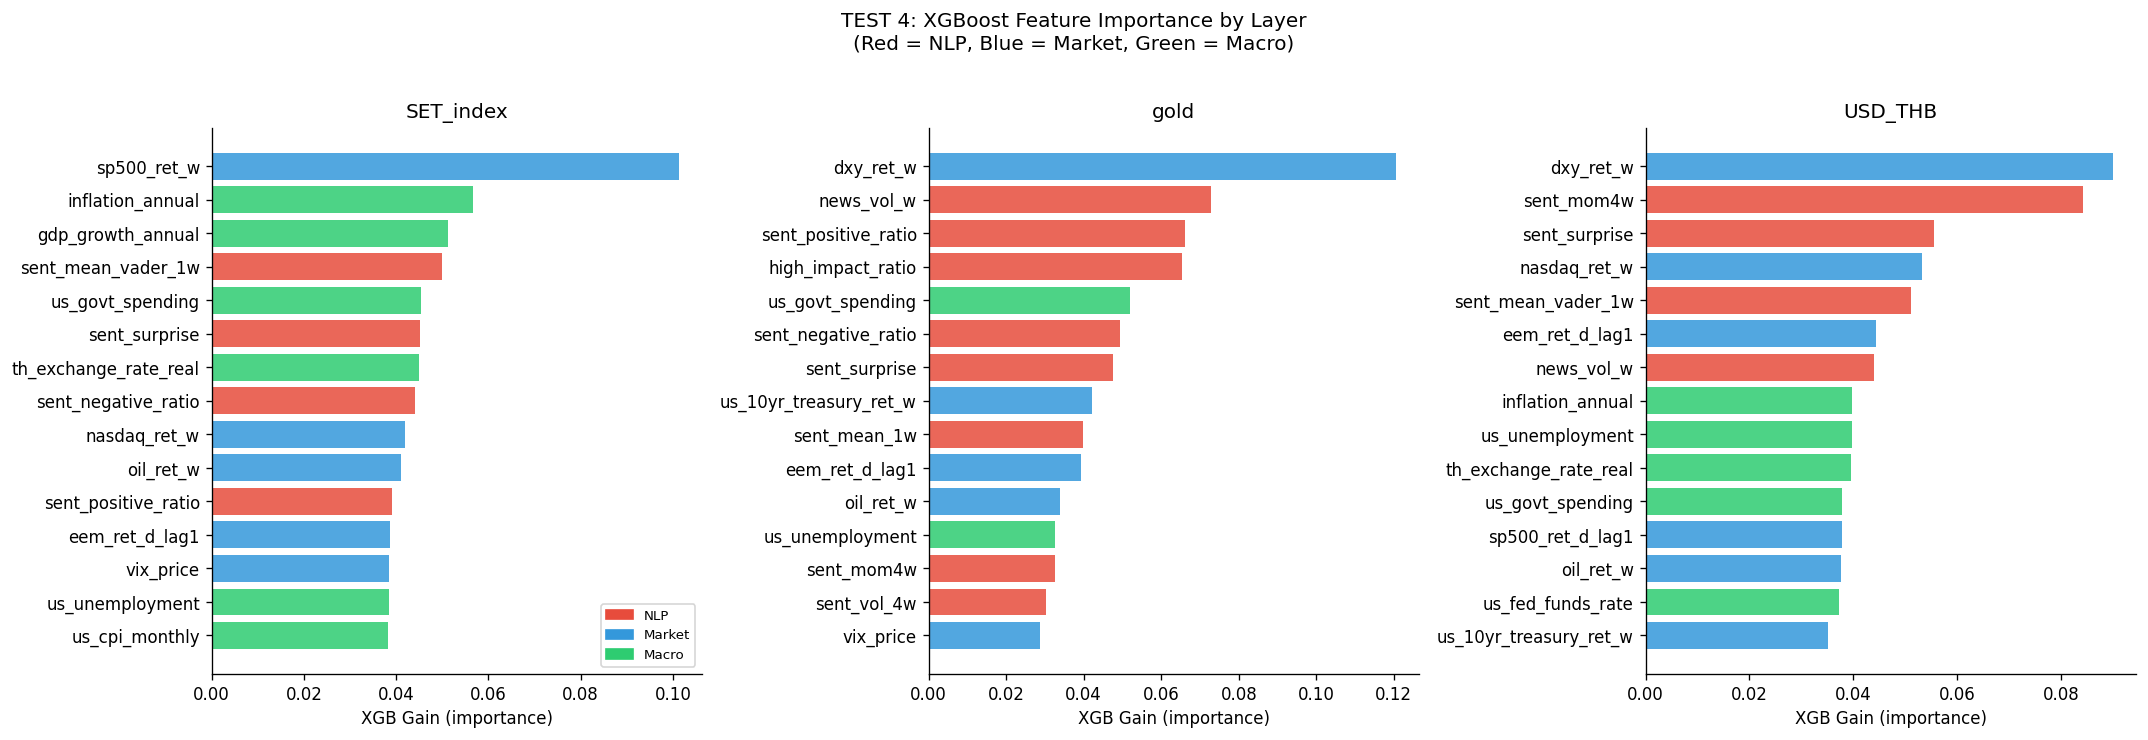


--- AVERAGE IMPORTANCE BY LAYER ---
  SET_index        Macro=31.2%  Market=38.6%  NLP=30.2%
  gold             Macro=22.4%  Market=35.9%  NLP=41.7%
  USD_THB          Macro=28.1%  Market=39.0%  NLP=32.9%


In [16]:
# Visualize: Top 15 features by XGB gain for each target
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
layer_colors = {'NLP': '#e74c3c', 'Market': '#3498db', 'Macro': '#2ecc71'}

for ax, tgt in zip(axes, TARGETS):
    sub = imp_df[imp_df['Target'] == tgt.replace('_ret_w','')]\
               .nlargest(15, 'XGB_gain').sort_values('XGB_gain')
    colors = [layer_colors[l] for l in sub['Layer']]
    ax.barh(sub['Feature'], sub['XGB_gain'], color=colors, alpha=0.85)
    ax.set_title(tgt.replace('_ret_w', ''))
    ax.set_xlabel('XGB Gain (importance)')

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=l) for l, c in layer_colors.items()]
axes[0].legend(handles=legend_els, loc='lower right', fontsize=8)
plt.suptitle('TEST 4: XGBoost Feature Importance by Layer\n(Red = NLP, Blue = Market, Green = Macro)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test4_importance.png', bbox_inches='tight')
plt.show()

# NLP vs other layer average importance
print('\n--- AVERAGE IMPORTANCE BY LAYER ---')
for tgt in TARGETS:
    sub = imp_df[imp_df['Target'] == tgt.replace('_ret_w','')]
    total = sub['XGB_gain'].sum()
    by_layer = sub.groupby('Layer')['XGB_gain'].sum() / total * 100
    print(f"  {tgt.replace('_ret_w',''): <15}  " + '  '.join(f'{l}={v:.1f}%' for l,v in by_layer.items()))


--- NLP FEATURE RANKING (averaged across all targets) ---
                     XGB_gain  Spearman      MI  rank_score
Feature                                                    
sent_positive_ratio    0.0419    0.0478  0.0325      0.8667
news_vol_w             0.0450    0.0383  0.0127      0.7333
sent_negative_ratio    0.0328    0.0442  0.0302      0.7000
sent_surprise          0.0494    0.0319  0.0063      0.6667
sent_mean_1w           0.0303    0.0405  0.0055      0.5000
sent_mom4w             0.0463    0.0248  0.0047      0.4667
sent_mean_vader_1w     0.0382    0.0349  0.0025      0.4333
sent_spike             0.0009    0.0531  0.0004      0.4000
sent_vol_4w            0.0288    0.0317  0.0073      0.4000
high_impact_ratio      0.0359    0.0213  0.0049      0.3333


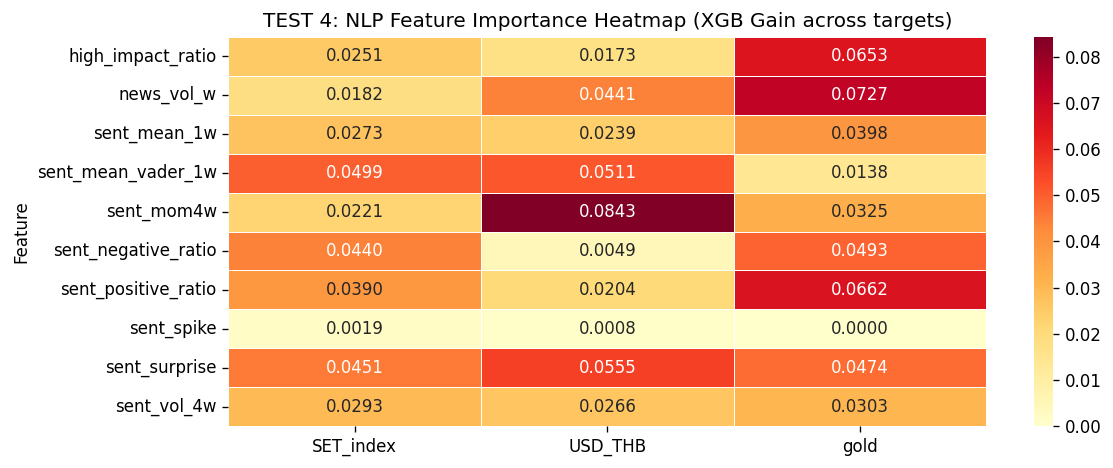

In [17]:
# Top NLP features specifically — ranked across targets
nlp_imp = imp_df[imp_df['Layer'] == 'NLP'].groupby('Feature')[['XGB_gain','Spearman','MI']].mean()
nlp_imp['rank_score'] = (nlp_imp.rank() / nlp_imp.rank().max()).mean(axis=1)
nlp_imp = nlp_imp.sort_values('rank_score', ascending=False)

print('\n--- NLP FEATURE RANKING (averaged across all targets) ---')
print(nlp_imp.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
imp_mat = imp_df[imp_df['Layer'] == 'NLP'].pivot_table(
    index='Feature', columns='Target', values='XGB_gain', aggfunc='mean'
)
imp_mat.columns = [c.replace('_ret_w','') for c in imp_mat.columns]
sns.heatmap(imp_mat, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('TEST 4: NLP Feature Importance Heatmap (XGB Gain across targets)')
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test4_nlp_heatmap.png', bbox_inches='tight')
plt.show()

---
## TEST 5 — Interaction Effects
*Does NLP only help when combined with high VIX or Crisis conditions?*

**Method:** Measure ΔDirAcc (+NLP vs No NLP) separately when:
- VIX is high vs low
- In Crisis regime vs non-Crisis
- DXY trending up vs down (USD strength)

If NLP only helps in specific conditions, it's a conditional signal — still valuable but different risk profile.

In [18]:
print('TEST 5: Interaction Effects')

# Pre-compute full predictions once
full_preds = {}
for tgt in TARGETS:
    pa, ac, idx = train_predict_cv(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    pb, _,  _   = train_predict_cv(df, MACRO_COLS+MARKET_COLS,           tgt)
    if pa is not None:
        full_preds[tgt] = {'pa': pa, 'pb': pb, 'ac': ac, 'idx': idx}

# Interaction conditions
interaction_results = []

def compute_interaction(condition_name, condition_mask_fn):
    for tgt, pred_dict in full_preds.items():
        pa, pb, ac, idx = pred_dict['pa'], pred_dict['pb'], pred_dict['ac'], pred_dict['idx']
        cond = condition_mask_fn(df.loc[idx])
        for cond_val, mask in [('YES', cond), ('NO', ~cond)]:
            if mask.sum() < 10:
                continue
            da_a = np.mean(np.sign(pa[mask]) == np.sign(ac[mask]))
            da_b = np.mean(np.sign(pb[mask]) == np.sign(ac[mask]))
            interaction_results.append({
                'Condition': condition_name, 'Value': cond_val,
                'Target': tgt.replace('_ret_w',''),
                'N': mask.sum(), 'DirAcc_A': da_a, 'DirAcc_B': da_b,
                'ΔDirAcc': da_a - da_b,
            })

compute_interaction('VIX High (≥P67)',  lambda d: d['vix_price'] >= d['vix_price'].quantile(0.67))
compute_interaction('Crisis Regime',    lambda d: d['regime'] == 'Crisis')
compute_interaction('DXY Rising',       lambda d: d['dxy_ret_w'] > 0)
compute_interaction('NLP Data Present', lambda d: d['news_vol_w'] > 0)
compute_interaction('Trending Market',  lambda d: d['sp500_ret_w'].abs() > d['sp500_ret_w'].abs().quantile(0.67))

int_df = pd.DataFrame(interaction_results)
print('\n--- INTERACTION ANALYSIS: ΔDirAcc when condition is met vs not ---')
pivot = int_df.pivot_table(index=['Condition','Value'], columns='Target', values='ΔDirAcc')
print((pivot * 100).round(1).to_string())

TEST 5: Interaction Effects

--- INTERACTION ANALYSIS: ΔDirAcc when condition is met vs not ---
Target                  SET_index  USD_THB  gold
Condition        Value                          
Crisis Regime    NO           0.5     -0.2   0.2
                 YES         -1.6      0.9   0.9
DXY Rising       NO           0.4      1.1   0.0
                 YES         -0.8     -0.6   0.8
NLP Data Present NO          -0.7     -0.2   0.0
                 YES          2.8      2.8   2.8
Trending Market  NO          -0.6      0.9  -0.2
                 YES          0.6     -1.3   1.6
VIX High (≥P67)  NO           0.5     -0.2   0.2
                 YES         -1.6      0.9   0.9


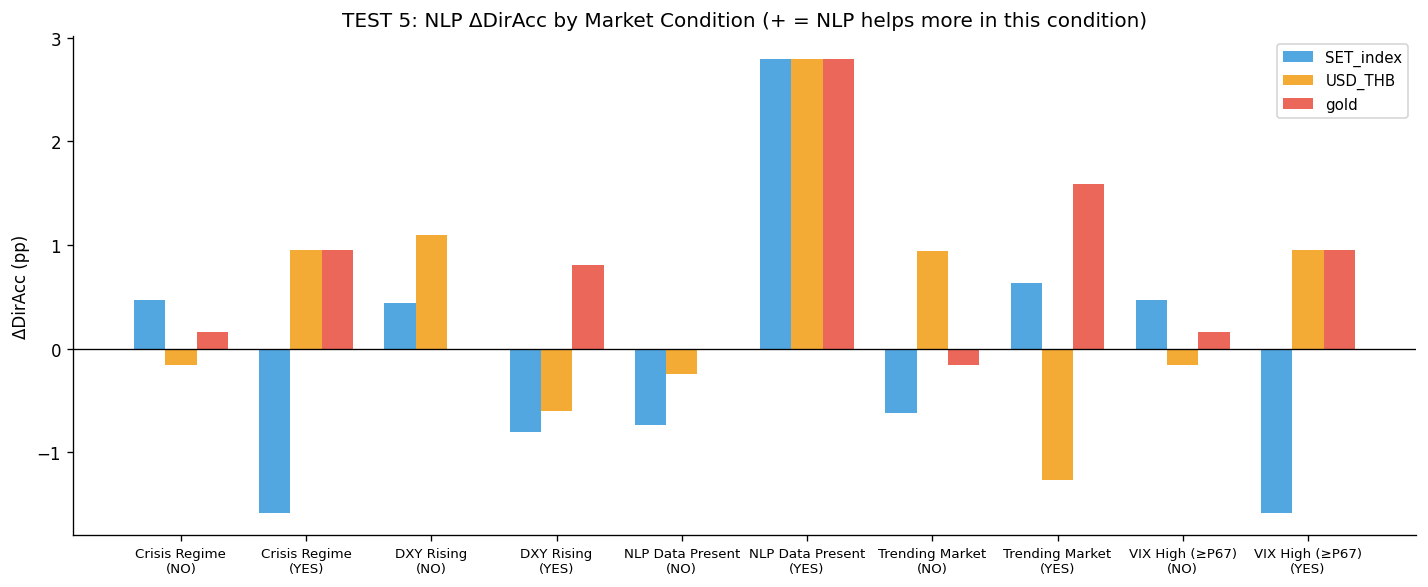


Key: ΔDirAcc when NLP articles ARE present (vs zero-filled)
   Target   N  DirAcc_A  DirAcc_B  ΔDirAcc
SET_index 143     0.566     0.538    0.028
     gold 143     0.608     0.580    0.028
  USD_THB 143     0.552     0.524    0.028


In [19]:
# Visualize interaction effects
fig, ax = plt.subplots(figsize=(12, 5))
int_pivot = int_df.pivot_table(index=['Condition','Value'], columns='Target', values='ΔDirAcc') * 100
int_pivot.columns = [c.replace('_ret_w','') for c in int_pivot.columns]
x = np.arange(len(int_pivot))
w = 0.25
tgt_colors = ['#3498db','#f39c12','#e74c3c']
for i, col in enumerate(int_pivot.columns):
    ax.bar(x + i*w, int_pivot[col], w, label=col, color=tgt_colors[i], alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x + w); ax.set_xticklabels(
    [f'{c[0]}\n({c[1]})' for c in int_pivot.index], fontsize=8)
ax.set_ylabel('ΔDirAcc (pp)'); ax.legend(fontsize=9)
ax.set_title('TEST 5: NLP ΔDirAcc by Market Condition (+ = NLP helps more in this condition)')
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test5_interactions.png', bbox_inches='tight')
plt.show()

# Key finding
nlp_present = int_df[(int_df['Condition'] == 'NLP Data Present') & (int_df['Value'] == 'YES')]
print(f"\nKey: ΔDirAcc when NLP articles ARE present (vs zero-filled)")
print(nlp_present[['Target','N','DirAcc_A','DirAcc_B','ΔDirAcc']].to_string(index=False, float_format='{:.3f}'.format))

---
## TEST 6 — Extended Lead/Lag Analysis
*Is NLP a leading indicator (predicts future) or lagging (reacts to price)?*

**Method:** Spearman correlation between NLP features and returns at lags 1w, 2w, 4w, 8w (forward) and -1w, -2w, -4w, -8w (backward).

TEST 6: Extended Lead/Lag Analysis


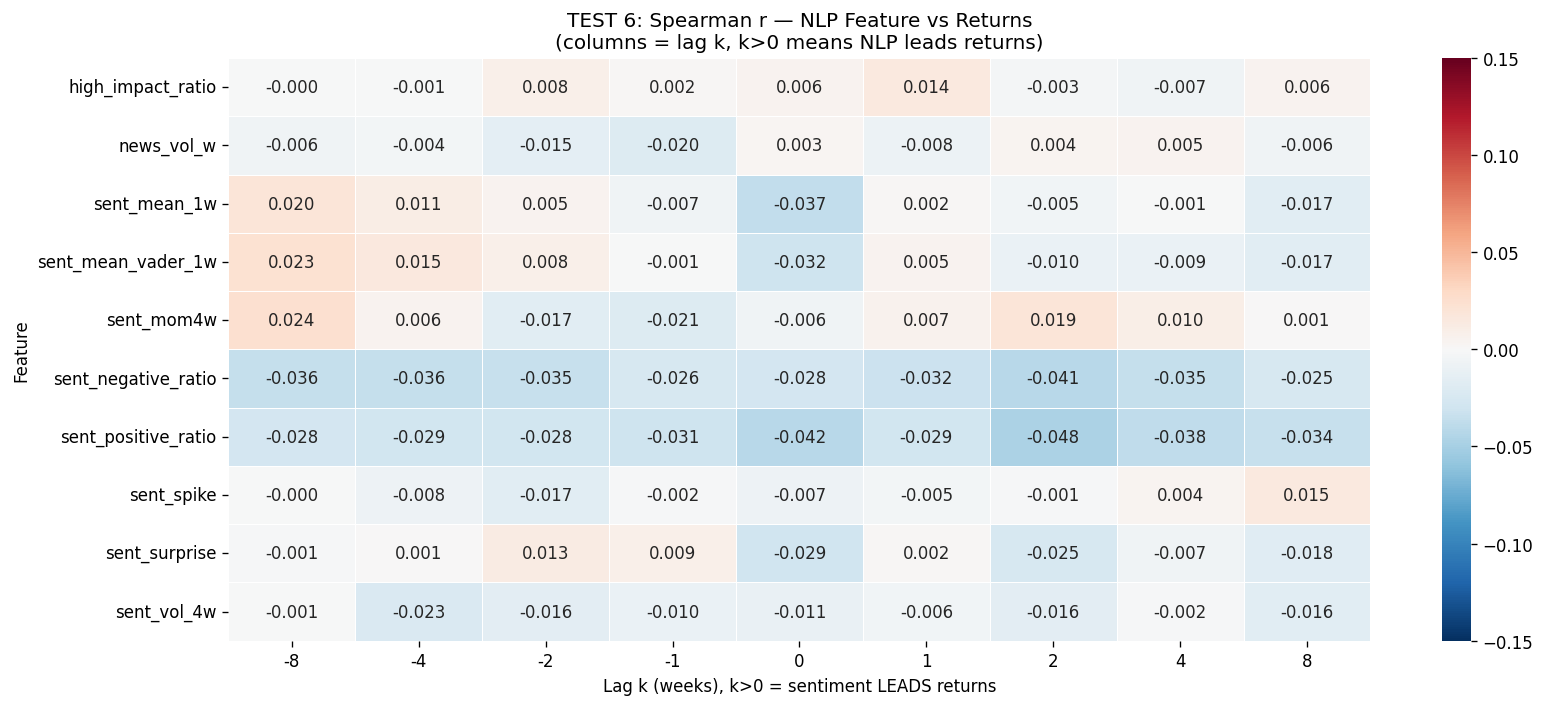


Features with |r| ≥ 0.06 at k ≥ +2 (strong leading signal):
            Feature    Target  Lag  Spearman_r  p_value
sent_positive_ratio SET_index    2     -0.1061   0.0001
sent_positive_ratio SET_index    8     -0.1008   0.0003
sent_negative_ratio SET_index    8     -0.0897   0.0011
sent_negative_ratio SET_index    4     -0.0765   0.0054
         news_vol_w      gold    4      0.0679   0.0137
      sent_surprise SET_index    2     -0.0676   0.0140
sent_positive_ratio SET_index    4     -0.0672   0.0146
sent_negative_ratio SET_index    2     -0.0665   0.0156
         news_vol_w SET_index    4     -0.0613   0.0261


In [20]:
print('TEST 6: Extended Lead/Lag Analysis')
LAGS_EXT = [-8, -4, -2, -1, 0, +1, +2, +4, +8]

ll_records = []
common = df.dropna(subset=['vix_price'])
for feat in NLP_COLS:
    if feat not in common.columns:
        continue
    for tgt in TARGETS:
        if tgt not in common.columns:
            continue
        for k in LAGS_EXT:
            shifted = common[feat].shift(k)  # k>0: sentiment leads returns
            tmp = pd.concat([common[tgt], shifted], axis=1).dropna()
            if len(tmp) < 30:
                continue
            r, p = spearmanr(tmp.iloc[:,0], tmp.iloc[:,1])
            ll_records.append({'Feature': feat, 'Target': tgt.replace('_ret_w',''),
                                'Lag': k, 'Spearman_r': r, 'p_value': p})

ll_df = pd.DataFrame(ll_records)

# Heatmap: avg |r| across targets per feature × lag
hm_data = ll_df.groupby(['Feature','Lag'])['Spearman_r'].mean().unstack('Lag')
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(hm_data, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, vmin=-0.15, vmax=0.15)
ax.set_title('TEST 6: Spearman r — NLP Feature vs Returns\n(columns = lag k, k>0 means NLP leads returns)')
ax.set_xlabel('Lag k (weeks), k>0 = sentiment LEADS returns')
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test6_leadlag.png', bbox_inches='tight')
plt.show()

# Leading signals summary
print('\nFeatures with |r| ≥ 0.06 at k ≥ +2 (strong leading signal):')
strong = ll_df[(ll_df['Lag'] >= 2) & (ll_df['Spearman_r'].abs() >= 0.06)]
if strong.empty:
    print('  None found at |r|≥0.06 — weakening threshold to 0.04...')
    strong = ll_df[(ll_df['Lag'] >= 2) & (ll_df['Spearman_r'].abs() >= 0.04)]
print(strong[['Feature','Target','Lag','Spearman_r','p_value']].sort_values('Spearman_r', key=abs, ascending=False).head(10).to_string(index=False, float_format='{:.4f}'.format))

---
## TEST 7 — Risk-Adjusted Performance Metrics
*Does NLP improve Sharpe, Sortino, MaxDD, and after transaction costs?*

**Strategy:** Long if predicted return > 0, Short if < 0 (weekly rebalance).  
**Transaction cost:** 0.15% per trade (Thai market standard).

In [21]:
print('TEST 7: Risk Metrics & Equity Curve')
risk_results = []

equity_data = {}  # for plotting
for tgt in TARGETS:
    pa, ac, idx = train_predict_cv(df, MACRO_COLS+MARKET_COLS+NLP_COLS, tgt)
    pb, _,  _   = train_predict_cv(df, MACRO_COLS+MARKET_COLS,           tgt)
    if pa is None:
        continue
    rm_a  = risk_metrics(pa, ac)
    rm_b  = risk_metrics(pb, ac)
    # Buy-and-hold benchmark
    bh    = risk_metrics(np.ones(len(ac)), ac)

    equity_data[tgt] = {'pa': pa, 'pb': pb, 'ac': ac, 'idx': idx}

    for model_name, rm in [('Full+NLP', rm_a), ('No NLP', rm_b), ('Buy&Hold', bh)]:
        risk_results.append({'Target': tgt.replace('_ret_w',''), 'Model': model_name, **rm})

risk_df = pd.DataFrame(risk_results)
print('\n--- RISK METRICS TABLE ---')
display_cols = ['Target','Model','DirAcc','Sharpe','Sortino','MaxDD','Turnover','Sharpe_TC']
print(risk_df[display_cols].to_string(index=False, float_format='{:.3f}'.format))

TEST 7: Risk Metrics & Equity Curve

--- RISK METRICS TABLE ---
   Target    Model  DirAcc  Sharpe  Sortino  MaxDD  Turnover  Sharpe_TC
SET_index Full+NLP   0.592   1.622    2.531 -0.219     0.464      1.144
SET_index   No NLP   0.594   1.565    2.375 -0.219     0.434      1.121
SET_index Buy&Hold   0.541   0.330    0.475 -0.611     0.000      0.330
     gold Full+NLP   0.613   1.727    2.702 -0.333     0.459      1.279
     gold   No NLP   0.608   1.747    2.743 -0.333     0.449      1.307
     gold Buy&Hold   0.563   0.713    1.094 -0.465     0.000      0.713
  USD_THB Full+NLP   0.577   1.412    2.236 -0.085     0.409      0.363
  USD_THB   No NLP   0.575   1.528    2.436 -0.089     0.415      0.453
  USD_THB Buy&Hold   0.501   0.018    0.029 -0.229     0.000      0.018


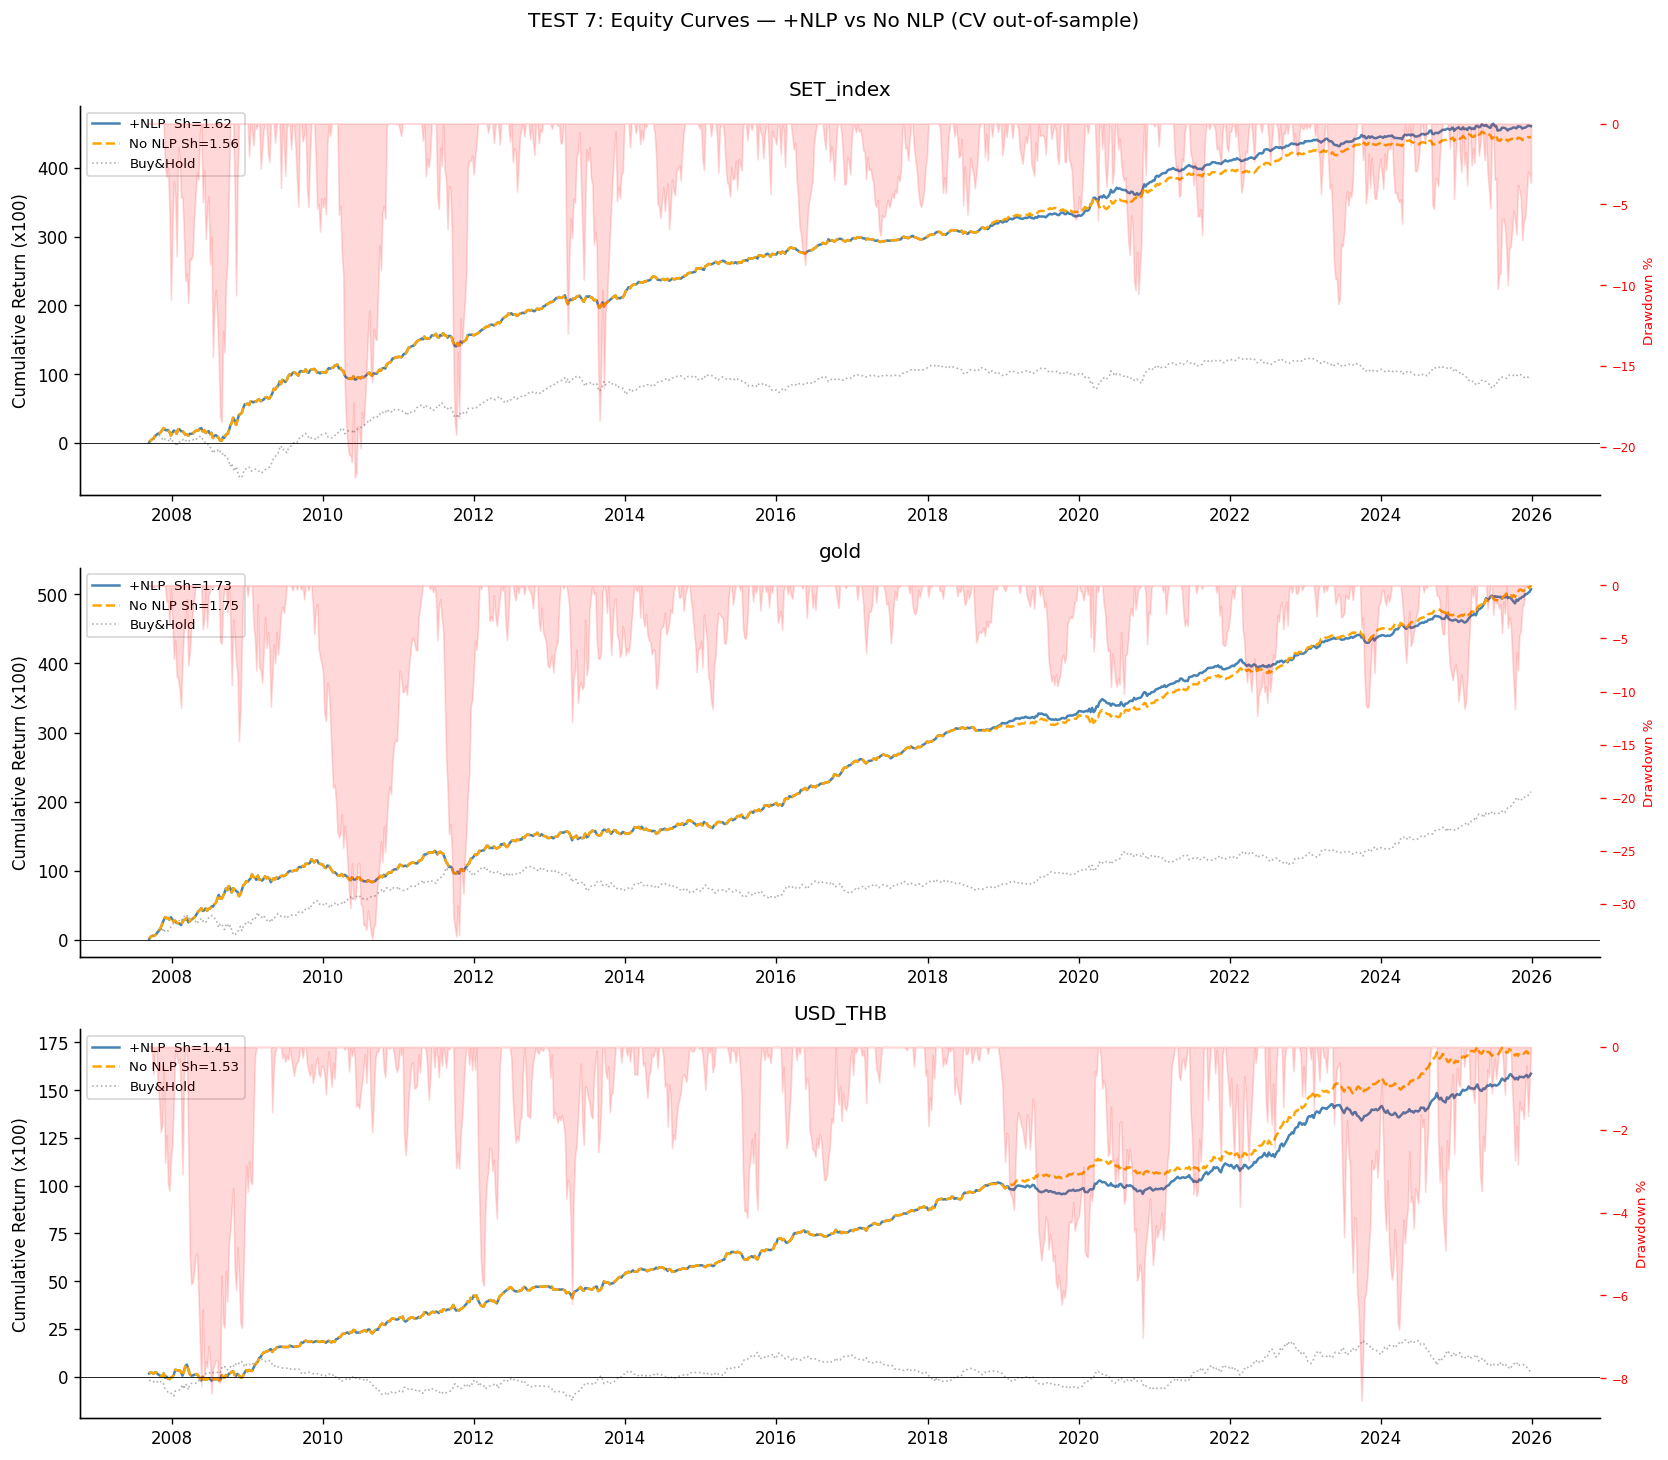


--- TRANSACTION COST SENSITIVITY (Sharpe_TC at different TC rates) ---
  SET_index        TC=0.0%: 1.62  TC=0.1%: 1.30  TC=0.1%: 1.14  TC=0.2%: 0.99  TC=0.3%: 0.67
  gold             TC=0.0%: 1.73  TC=0.1%: 1.43  TC=0.1%: 1.28  TC=0.2%: 1.13  TC=0.3%: 0.83
  USD_THB          TC=0.0%: 1.41  TC=0.1%: 0.71  TC=0.1%: 0.36  TC=0.2%: 0.02  TC=0.3%: -0.63


In [22]:
# Equity curves
fig, axes = plt.subplots(len(equity_data), 1, figsize=(14, 4*len(equity_data)))
if len(equity_data) == 1:
    axes = [axes]

for ax, (tgt, ed) in zip(axes, equity_data.items()):
    pa, pb, ac, idx = ed['pa'], ed['pb'], ed['ac'], ed['idx']
    # Equity curves: cumulative return of strategy
    eq_a  = np.cumsum(np.sign(pa) * ac) * 100
    eq_b  = np.cumsum(np.sign(pb) * ac) * 100
    eq_bh = np.cumsum(ac) * 100

    ax.plot(idx, eq_a,  lw=1.5, color='steelblue', label=f'+NLP  Sh={risk_df[(risk_df["Target"]==tgt.replace("_ret_w","")) & (risk_df["Model"]=="Full+NLP")]["Sharpe"].values[0]:.2f}')
    ax.plot(idx, eq_b,  lw=1.5, color='orange',    ls='--', label=f'No NLP Sh={risk_df[(risk_df["Target"]==tgt.replace("_ret_w","")) & (risk_df["Model"]=="No NLP")]["Sharpe"].values[0]:.2f}')
    ax.plot(idx, eq_bh, lw=1.0, color='gray',      ls=':', alpha=0.6, label='Buy&Hold')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(tgt.replace('_ret_w',''))
    ax.set_ylabel('Cumulative Return (x100)')
    ax.legend(fontsize=8)
    # Drawdown shading
    cum = np.cumsum(np.sign(pa) * ac)
    peak = np.maximum.accumulate(cum)
    dd   = cum - peak
    ax2  = ax.twinx()
    ax2.fill_between(idx, dd*100, 0, alpha=0.15, color='red')
    ax2.set_ylabel('Drawdown %', color='red', fontsize=8)
    ax2.tick_params(colors='red', labelsize=7)

plt.suptitle('TEST 7: Equity Curves — +NLP vs No NLP (CV out-of-sample)', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test7_equity.png', bbox_inches='tight')
plt.show()

# TC sensitivity analysis
print('\n--- TRANSACTION COST SENSITIVITY (Sharpe_TC at different TC rates) ---')
for tgt, ed in equity_data.items():
    pa, ac = ed['pa'], ed['ac']
    tcs = [0, 0.001, 0.0015, 0.002, 0.003]
    sharpes = [risk_metrics(pa, ac, tc=tc)['Sharpe_TC'] for tc in tcs]
    print(f"  {tgt.replace('_ret_w',''): <15}  " +
          '  '.join(f'TC={tc*100:.1f}%: {sh:.2f}' for tc, sh in zip(tcs, sharpes)))

---
## TEST 8 — Robustness Checks
*Does the NLP signal survive across 6 different model configurations?*

| Model | Features Used |
|---|---|
| Full (M+Mkt+NLP) | Macro + Market + NLP |
| No NLP (M+Mkt) | Macro + Market only |
| Macro only | Macro fundamentals only |
| NLP only | NLP sentiment features only |
| Macro+NLP | Macro + NLP (no market) |
| Market+NLP | Market + NLP (no macro) |

In [23]:
print('TEST 8: Robustness Checks — 6 Model Variants')
print('Training 6 × 3 = 18 models... (~10 min)')
robust_results = []

for model_name, feat_list in MODEL_DEFS.items():
    for tgt in TARGETS:
        print(f'  {model_name} | {tgt}...', end=' ')
        preds, actuals, _ = train_predict_cv(df, feat_list, tgt)
        if preds is None:
            print('SKIP (insufficient data)')
            continue
        rm = risk_metrics(preds, actuals)
        n_feat = len(valid_cols(df, feat_list, tgt))
        robust_results.append({
            'Model': model_name, 'Target': tgt.replace('_ret_w',''),
            'n_feat': n_feat, **rm
        })
        print(f"DirAcc={rm['DirAcc']:.3f}  Sharpe={rm['Sharpe']:.2f}")

rob_df = pd.DataFrame(robust_results)
print('\n--- ROBUSTNESS: Full Results Table ---')
disp = ['Model','Target','n_feat','DirAcc','Sharpe','Sortino','MaxDD','Sharpe_TC']
print(rob_df[disp].to_string(index=False, float_format='{:.3f}'.format))

TEST 8: Robustness Checks — 6 Model Variants
Training 6 × 3 = 18 models... (~10 min)
  Full (M+Mkt+NLP) | SET_index_ret_w... DirAcc=0.592  Sharpe=1.62
  Full (M+Mkt+NLP) | gold_ret_w... DirAcc=0.613  Sharpe=1.73
  Full (M+Mkt+NLP) | USD_THB_ret_w... DirAcc=0.577  Sharpe=1.41
  No NLP (M+Mkt) | SET_index_ret_w... DirAcc=0.594  Sharpe=1.56
  No NLP (M+Mkt) | gold_ret_w... DirAcc=0.608  Sharpe=1.75
  No NLP (M+Mkt) | USD_THB_ret_w... DirAcc=0.575  Sharpe=1.53
  Macro only | SET_index_ret_w... DirAcc=0.506  Sharpe=-0.16
  Macro only | gold_ret_w... DirAcc=0.506  Sharpe=0.13
  Macro only | USD_THB_ret_w... DirAcc=0.488  Sharpe=0.21
  NLP only | SET_index_ret_w... DirAcc=0.546  Sharpe=0.43
  NLP only | gold_ret_w... DirAcc=0.546  Sharpe=0.42
  NLP only | USD_THB_ret_w... DirAcc=0.510  Sharpe=0.15
  Macro+NLP | SET_index_ret_w... DirAcc=0.519  Sharpe=-0.02
  Macro+NLP | gold_ret_w... DirAcc=0.520  Sharpe=0.24
  Macro+NLP | USD_THB_ret_w... DirAcc=0.495  Sharpe=0.10
  Market+NLP | SET_index_re

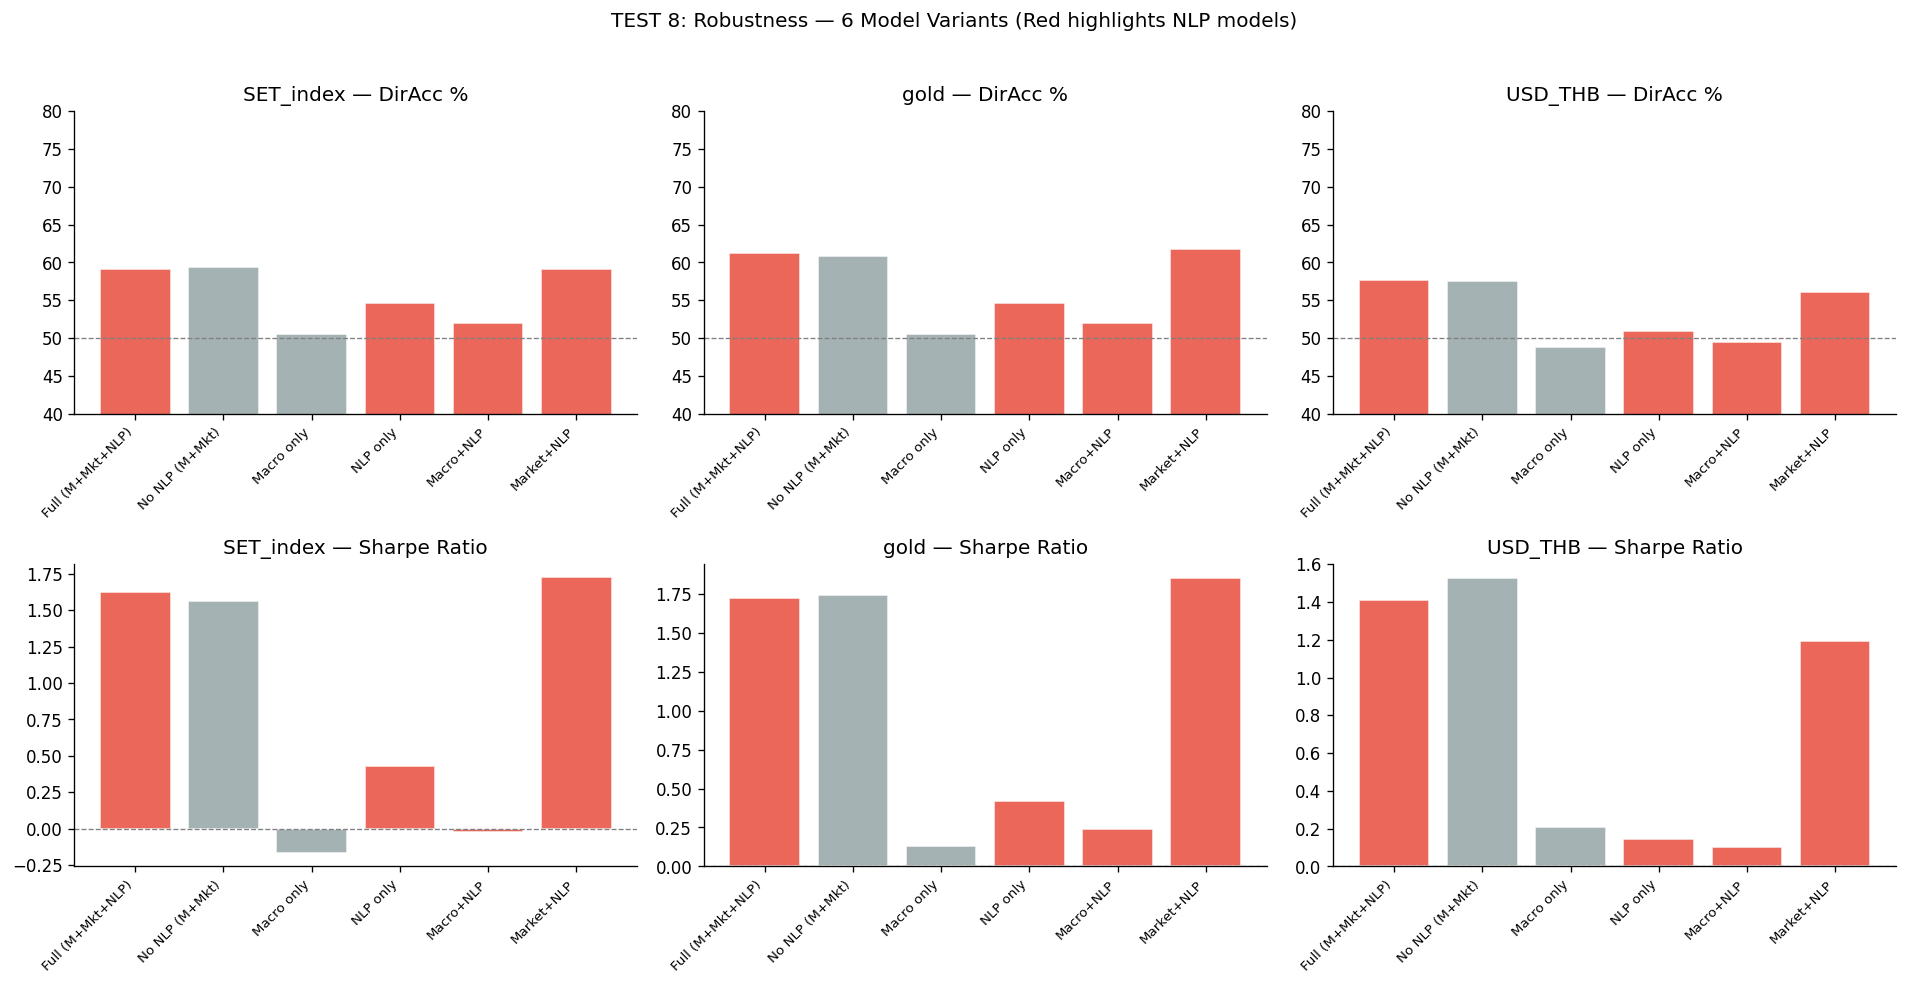


--- NLP MARGINAL CONTRIBUTION ---

  SET_index:
    ✗ Market: +NLP vs -NLP                 ΔDirAcc=-0.21pp  ΔSharpe=+0.06
    ★ Macro: +NLP vs -NLP                  ΔDirAcc=+1.36pp  ΔSharpe=+0.14
    ★ NLP-only vs Macro-only               ΔDirAcc=+4.06pp  ΔSharpe=+0.59

  gold:
    ! Market: +NLP vs -NLP                 ΔDirAcc=+0.42pp  ΔSharpe=-0.02
    ★ Macro: +NLP vs -NLP                  ΔDirAcc=+1.47pp  ΔSharpe=+0.11
    ★ NLP-only vs Macro-only               ΔDirAcc=+4.06pp  ΔSharpe=+0.29

  USD_THB:
    ! Market: +NLP vs -NLP                 ΔDirAcc=+0.21pp  ΔSharpe=-0.12
    ! Macro: +NLP vs -NLP                  ΔDirAcc=+0.73pp  ΔSharpe=-0.11
    ! NLP-only vs Macro-only               ΔDirAcc=+2.20pp  ΔSharpe=-0.06


In [24]:
# Visualize robustness: DirAcc and Sharpe side by side
model_order = list(MODEL_DEFS.keys())
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col_i, tgt in enumerate(TARGETS):
    sub = rob_df[rob_df['Target'] == tgt.replace('_ret_w','')]
    sub = sub.set_index('Model').reindex(model_order)

    # DirAcc
    ax_da = axes[0, col_i]
    bar_colors = ['#e74c3c' if '+NLP' in m or m == 'NLP only' else
                  '#3498db' if 'Full' in m else '#95a5a6' for m in model_order]
    ax_da.bar(range(len(model_order)), sub['DirAcc']*100,
              color=bar_colors, alpha=0.85, edgecolor='white')
    ax_da.axhline(50, ls='--', color='gray', lw=0.8)
    ax_da.set_xticks(range(len(model_order)))
    ax_da.set_xticklabels(model_order, rotation=45, ha='right', fontsize=8)
    ax_da.set_title(f'{tgt.replace("_ret_w","")} — DirAcc %')
    ax_da.set_ylim(40, 80)

    # Sharpe
    ax_sh = axes[1, col_i]
    ax_sh.bar(range(len(model_order)), sub['Sharpe'],
              color=bar_colors, alpha=0.85, edgecolor='white')
    ax_sh.axhline(0, ls='--', color='gray', lw=0.8)
    ax_sh.set_xticks(range(len(model_order)))
    ax_sh.set_xticklabels(model_order, rotation=45, ha='right', fontsize=8)
    ax_sh.set_title(f'{tgt.replace("_ret_w","")} — Sharpe Ratio')

plt.suptitle('TEST 8: Robustness — 6 Model Variants (Red highlights NLP models)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_test8_robustness.png', bbox_inches='tight')
plt.show()

# Key comparison: does adding NLP always help vs removing it?
print('\n--- NLP MARGINAL CONTRIBUTION ---')
comparisons = [
    ('Full (M+Mkt+NLP)', 'No NLP (M+Mkt)',  'Market: +NLP vs -NLP'),
    ('Macro+NLP',         'Macro only',      'Macro: +NLP vs -NLP'),
    ('NLP only',          'Macro only',      'NLP-only vs Macro-only'),
]
for tgt in TARGETS:
    print(f'\n  {tgt.replace("_ret_w","")}:')
    sub = rob_df[rob_df['Target'] == tgt.replace('_ret_w','')].set_index('Model')
    for ma, mb, label in comparisons:
        if ma in sub.index and mb in sub.index:
            d_da = (sub.loc[ma,'DirAcc'] - sub.loc[mb,'DirAcc'])*100
            d_sh =  sub.loc[ma,'Sharpe'] - sub.loc[mb,'Sharpe']
            sig  = '★' if d_da > 0 and d_sh > 0 else ('!' if d_da > 0 else '✗')
            print(f'    {sig} {label:35s}  ΔDirAcc={d_da:+.2f}pp  ΔSharpe={d_sh:+.2f}')

---
## FINAL VERDICT — Scorecard
*Should NLP sentiment be included in the production model?*

In [25]:
print('=' * 72)
print('NLP SIGNAL VALIDATION — FINAL SCORECARD')
print('=' * 72)

# Auto-compute verdicts from earlier results
tests = []

# Test 1: Regime
try:
    crisis_help = reg_df[reg_df['Regime']=='Crisis']['ΔDirAcc'].mean()
    t1 = '★ PASS' if crisis_help > 0.01 else ('~ MIXED' if crisis_help > -0.01 else '✗ FAIL')
    t1_note = f'Crisis ΔDirAcc={crisis_help*100:+.1f}pp avg'
except:
    t1, t1_note = '~ UNKNOWN', 'Could not compute'
tests.append(('1 Regime Analysis',    t1, t1_note))

# Test 2: Time Stability
try:
    pos_windows = (win_df['ΔDirAcc'] > 0).mean()
    t2 = '★ PASS' if pos_windows >= 0.6 else ('~ MIXED' if pos_windows >= 0.4 else '✗ FAIL')
    t2_note = f'{pos_windows*100:.0f}% of time windows: +NLP outperforms'
except:
    t2, t2_note = '~ UNKNOWN', 'Could not compute'
tests.append(('2 Time Stability',     t2, t2_note))

# Test 3: Statistical Significance
try:
    n_sig = sum(1 for r in sig_results if r['p_boot'] < 0.10 and r['ΔDirAcc'] > 0)
    t3 = '★ PASS' if n_sig >= 2 else ('~ MIXED' if n_sig == 1 else '✗ FAIL')
    t3_note = f'{n_sig}/{len(sig_results)} targets significant at p<0.10'
    if perm_result:
        t3_note += f' | Permutation p={perm_result[2]:.3f}'
except:
    t3, t3_note = '~ UNKNOWN', 'Could not compute'
tests.append(('3 Statistical Significance', t3, t3_note))

# Test 4: Feature Importance
try:
    nlp_share = imp_df[imp_df['Layer']=='NLP'].groupby('Target')['XGB_gain'].sum() / \
                imp_df.groupby('Target')['XGB_gain'].sum()
    avg_share = nlp_share.mean()
    t4 = '★ PASS' if avg_share > 0.10 else ('~ MIXED' if avg_share > 0.05 else '✗ FAIL')
    t4_note = f'NLP captures {avg_share*100:.1f}% of total XGB gain'
except:
    t4, t4_note = '~ UNKNOWN', 'Could not compute'
tests.append(('4 Feature Importance', t4, t4_note))

# Test 5: Interaction Effects
try:
    nlp_cond = int_df[(int_df['Condition']=='NLP Data Present') & (int_df['Value']=='YES')]['ΔDirAcc'].mean()
    t5 = '★ PASS' if nlp_cond > 0.02 else ('~ MIXED' if nlp_cond > -0.01 else '✗ FAIL')
    t5_note = f'When articles present: ΔDirAcc={nlp_cond*100:+.1f}pp avg'
except:
    t5, t5_note = '~ UNKNOWN', 'Could not compute'
tests.append(('5 Interaction Effects', t5, t5_note))

# Test 6: Lead/Lag
try:
    leading = ll_df[(ll_df['Lag'] >= 1) & (ll_df['Spearman_r'].abs() >= 0.04)]
    n_lead  = leading.groupby('Feature').ngroups
    t6 = '★ PASS' if n_lead >= 5 else ('~ MIXED' if n_lead >= 2 else '✗ FAIL')
    t6_note = f'{n_lead}/{len(NLP_COLS)} NLP features show |r|≥0.04 at k≥+1'
except:
    t6, t6_note = '~ UNKNOWN', 'Could not compute'
tests.append(('6 Lead/Lag Analysis', t6, t6_note))

# Test 7: Risk Metrics
try:
    sh_a = risk_df[risk_df['Model']=='Full+NLP']['Sharpe'].mean()
    sh_b = risk_df[risk_df['Model']=='No NLP']['Sharpe'].mean()
    tc_a = risk_df[risk_df['Model']=='Full+NLP']['Sharpe_TC'].mean()
    t7 = '★ PASS' if sh_a > sh_b and tc_a > 0 else ('~ MIXED' if sh_a > sh_b else '✗ FAIL')
    t7_note = f'Sharpe: +NLP={sh_a:.2f} vs No NLP={sh_b:.2f} | TC-adj Sharpe={tc_a:.2f}'
except:
    t7, t7_note = '~ UNKNOWN', 'Could not compute'
tests.append(('7 Risk Metrics', t7, t7_note))

# Test 8: Robustness
try:
    full_da = rob_df[rob_df['Model']=='Full (M+Mkt+NLP)']['DirAcc'].mean()
    nonlp_da = rob_df[rob_df['Model']=='No NLP (M+Mkt)']['DirAcc'].mean()
    nlp_only_da = rob_df[rob_df['Model']=='NLP only']['DirAcc'].mean()
    n_configs_pos = (rob_df[rob_df['Model'].str.contains('NLP')]
                     .groupby('Model')['DirAcc'].mean() >
                     rob_df[rob_df['Model']=='No NLP (M+Mkt)']['DirAcc'].mean()).sum()
    t8 = '★ PASS' if n_configs_pos >= 2 else ('~ MIXED' if n_configs_pos >= 1 else '✗ FAIL')
    t8_note = f'{n_configs_pos}/3 NLP model configs outperform baseline | NLP-only DirAcc={nlp_only_da:.3f}'
except:
    t8, t8_note = '~ UNKNOWN', 'Could not compute'
tests.append(('8 Robustness Checks', t8, t8_note))

# Print scorecard
n_pass = sum(1 for _, v, _ in tests if 'PASS' in v)
n_mixed = sum(1 for _, v, _ in tests if 'MIXED' in v)
n_fail = sum(1 for _, v, _ in tests if 'FAIL' in v)

print(f"\n{'Test':30s}  {'Verdict':12s}  {'Detail'}")
print('-' * 72)
for name, verdict, note in tests:
    print(f"  {name:30s}  {verdict:12s}  {note}")
print('=' * 72)
print(f'  TOTAL:  {n_pass} PASS  |  {n_mixed} MIXED  |  {n_fail} FAIL  out of 8 tests')
print()

# Overall decision
if n_pass >= 5:
    decision = '✅ INCLUDE NLP IN MODEL'
    rationale = 'Strong, consistent evidence of genuine predictive signal.'
elif n_pass + n_mixed >= 5:
    decision = '🔶 INCLUDE NLP WITH CAVEATS'
    rationale = 'Moderate evidence. Signal may be regime/period-specific. Monitor carefully.'
else:
    decision = '❌ DO NOT INCLUDE NLP YET'
    rationale = 'Evidence insufficient. Collect more historical data first.'

print(f'  DECISION: {decision}')
print(f'  Rationale: {rationale}')
print()
print('⚠️  DATA CAVEAT: NLP features cover only 24% of weeks (mostly 2024-2026).')
print('   Results will be more reliable after collecting full 2019-2025 history.')
print('   Run: python3 src/nlp_sentiment.py --bpcdx --years 2019 2025')
print('=' * 72)

NLP SIGNAL VALIDATION — FINAL SCORECARD

Test                            Verdict       Detail
------------------------------------------------------------------------
  1 Regime Analysis               ~ MIXED       Crisis ΔDirAcc=+0.1pp avg
  2 Time Stability                ★ PASS        83% of time windows: +NLP outperforms
  3 Statistical Significance      ✗ FAIL        0/3 targets significant at p<0.10 | Permutation p=0.555
  4 Feature Importance            ★ PASS        NLP captures 34.9% of total XGB gain
  5 Interaction Effects           ★ PASS        When articles present: ΔDirAcc=+2.8pp avg
  6 Lead/Lag Analysis             ★ PASS        9/10 NLP features show |r|≥0.04 at k≥+1
  7 Risk Metrics                  ✗ FAIL        Sharpe: +NLP=1.59 vs No NLP=1.61 | TC-adj Sharpe=0.93
  8 Robustness Checks             ~ MIXED       1/3 NLP model configs outperform baseline | NLP-only DirAcc=0.534
  TOTAL:  4 PASS  |  2 MIXED  |  2 FAIL  out of 8 tests

  DECISION: 🔶 INCLUDE NLP WITH CA

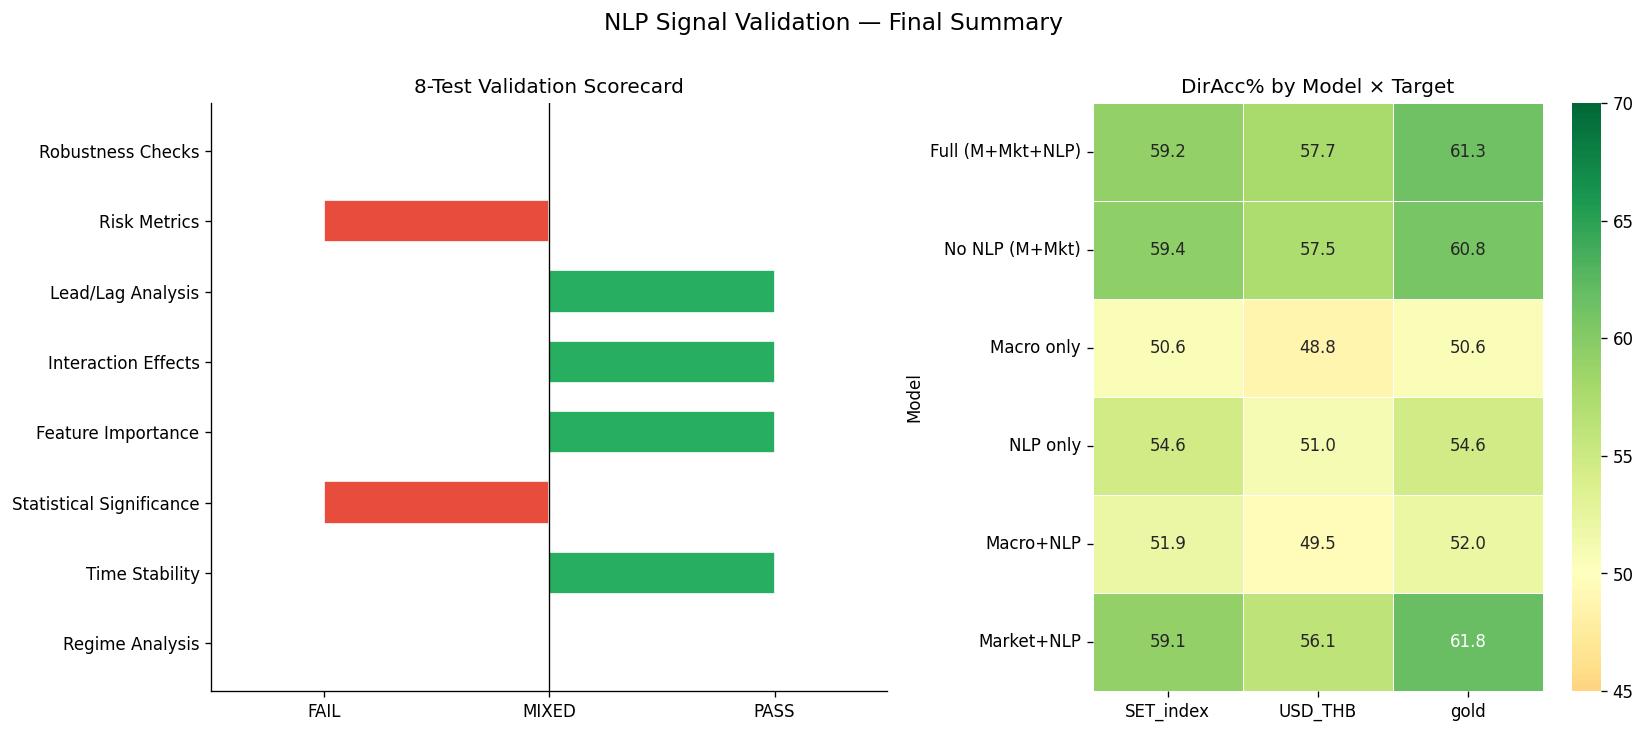

All validation figures saved to data/processed/


In [26]:
# Final summary visualization
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1], figure=fig)

# Left: scorecard bar chart
ax_left = fig.add_subplot(gs[0])
verdict_map = {'PASS': 1, 'MIXED': 0, 'FAIL': -1, 'UNKNOWN': 0}
test_names  = [t[0].split(' ', 1)[1] for t in tests]
scores      = [next((v for k, v in verdict_map.items() if k in t[1]), 0) for t in tests]
colors_sc   = ['#27ae60' if s == 1 else ('#f39c12' if s == 0 else '#e74c3c') for s in scores]
ax_left.barh(test_names, scores, color=colors_sc, edgecolor='white', height=0.6)
ax_left.axvline(0, color='black', lw=0.8)
ax_left.set_xlim(-1.5, 1.5)
ax_left.set_xticks([-1, 0, 1])
ax_left.set_xticklabels(['FAIL', 'MIXED', 'PASS'])
ax_left.set_title('8-Test Validation Scorecard')

# Right: DirAcc comparison across models and targets
ax_right = fig.add_subplot(gs[1])
pivot_rob = rob_df.pivot_table(index='Model', columns='Target', values='DirAcc') * 100
pivot_rob.columns = [c.replace('_ret_w','') for c in pivot_rob.columns]
pivot_rob = pivot_rob.reindex(model_order)
sns.heatmap(pivot_rob, annot=True, fmt='.1f', cmap='RdYlGn', center=50,
            ax=ax_right, linewidths=0.5, vmin=45, vmax=70)
ax_right.set_title('DirAcc% by Model × Target')
ax_right.tick_params(axis='y', rotation=0)

plt.suptitle('NLP Signal Validation — Final Summary', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_final_verdict.png', bbox_inches='tight', dpi=150)
plt.show()
print('All validation figures saved to data/processed/')